<a href="https://colab.research.google.com/github/daitianyuanya-code/brazilian-ecommerce-logistics-analysis/blob/main/olist_logistics_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Delivery Delay in Brazilian E-Commerce

## Research Question

How can e-commerce platforms use order characteristics, holiday-period indicators, seller workload, and logistics risk profiles to identify delivery-delay risks?

## Project Summary

This notebook predicts whether an Olist order was delivered later than its estimated delivery date. The analysis uses order-level logistics features, Brazilian public holiday and peak-season indicators, and a constructed **seller concurrent load** variable that captures how many active orders a seller was handling when a new order was placed.

The notebook combines EDA, K-Means clustering, and supervised classification models including Logistic Regression, Decision Tree, Random Forest, and XGBoost. The goal is to identify key delay-risk patterns and provide practical logistics recommendations.

## Data Sources

- Olist Brazilian E-Commerce Public Dataset:  
  https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

- Brazilian public holidays generated using the Python `holidays` package:  
  https://holidays.readthedocs.io/

## Notebook Structure

1. Setup & Data Loading  
2. Data Preprocessing  
3. External Data: Brazilian Public Holidays  
4. Exploratory Data Analysis  
5. K-Means Clustering  
6. Supervised Delay Classification  
7. Results & Business Recommendations

## 1. Setup & Data Loading

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates

In [4]:
# Load the six Olist CSV files from the GitHub data folder

BASE_URL = "https://raw.githubusercontent.com/daitianyuanya-code/brazilian-ecommerce-logistics-analysis/main/data/"

orders = pd.read_csv(BASE_URL + "olist_orders_dataset.csv")
items = pd.read_csv(BASE_URL + "olist_order_items_dataset.csv")
reviews = pd.read_csv(BASE_URL + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(BASE_URL + "olist_customers_dataset.csv")
sellers = pd.read_csv(BASE_URL + "olist_sellers_dataset.csv")
products = pd.read_csv(BASE_URL + "olist_products_dataset.csv")

print("Data loaded successfully.")
print("Orders:", orders.shape)
print("Items:", items.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)
print("Sellers:", sellers.shape)
print("Products:", products.shape)

Data loaded successfully.
Orders: (99441, 8)
Items: (112650, 7)
Reviews: (99224, 7)
Customers: (99441, 5)
Sellers: (3095, 4)
Products: (32951, 9)


## 2. Data Preprocessing

### 2.1 Merge Tables at Order Level

The unit of analysis is one order per row. Since the Olist dataset is split across several relational tables, I merge customer, seller, product, item, and review information into the orders table.

Some tables contain multiple rows per order, especially `order_items` and `reviews`. These tables are first aggregated to order level before merging to avoid duplicated order rows.

In [12]:
# ============================================================
# 2.1 Merge tables into one order-level analytical DataFrame
# ============================================================


# ------------------------------------------------------------
# Step 1: Start from the orders table and add customer location
# ------------------------------------------------------------
# Start from the orders table because the unit of analysis is one order.
# Add customer city and state to capture destination-side location information.

df = orders.merge(
    customers[['customer_id', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left'
)

print("After merging customer information:", df.shape)

After merging customer information: (99441, 10)


In [13]:
# ------------------------------------------------------------
# Step 2: Aggregate order item information to order level
# ------------------------------------------------------------
# The order_items table may contain multiple rows for the same order,
# because one order can include multiple items and, in some cases,
# multiple sellers.
#
# To keep the final dataset at order level, item-level variables are
# aggregated before merging. Price and freight are summed, item_count
# counts the number of items, seller_id keeps the first seller as a
# representative seller for merging seller location, and seller_count
# records the number of unique sellers involved in each order.

items_agg = items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    item_count=('order_item_id', 'count'),
    seller_id=('seller_id', 'first'),
    seller_count=('seller_id', 'nunique')
).reset_index()

df = df.merge(items_agg, on='order_id', how='left')

print("After merging aggregated order item information:", df.shape)

After merging aggregated order item information: (99441, 15)


In [14]:
# ------------------------------------------------------------
# Step 3: Add product characteristics at order level
# ------------------------------------------------------------
# Product information is first merged into the item-level table.
# Then product weight and product volume are aggregated to order level.
# This is necessary because one order may contain multiple products.
#
# product_category_name keeps the first category as a representative category,
# while product_category_count records how many unique product categories are
# included in each order.

items_products = items[['order_id', 'product_id']].merge(
    products[
        [
            'product_id',
            'product_category_name',
            'product_weight_g',
            'product_length_cm',
            'product_height_cm',
            'product_width_cm'
        ]
    ],
    on='product_id',
    how='left'
)

# Calculate product volume using length × height × width.
items_products['product_volume_cm3'] = (
    items_products['product_length_cm'] *
    items_products['product_height_cm'] *
    items_products['product_width_cm']
)

product_agg = items_products.groupby('order_id').agg(
    product_weight_g=('product_weight_g', 'sum'),
    product_volume_cm3=('product_volume_cm3', 'sum'),
    product_category_name=('product_category_name', 'first'),
    product_category_count=('product_category_name', 'nunique')
).reset_index()

df = df.merge(product_agg, on='order_id', how='left')

print("After merging aggregated product information:", df.shape)

After merging aggregated product information: (99441, 19)


In [15]:
# ------------------------------------------------------------
# Step 4: Add seller location
# ------------------------------------------------------------
# Seller state is added to capture supply-side location information.
# Since seller_id was aggregated at order level using the first seller,
# seller_state should be interpreted as the representative seller location.
# This variable is later used to compare customer and seller states.

df = df.merge(
    sellers[['seller_id', 'seller_state']],
    on='seller_id',
    how='left'
)

print("After merging seller information:", df.shape)

After merging seller information: (99441, 20)


In [16]:
# ------------------------------------------------------------
# Step 5: Add review score
# ------------------------------------------------------------
# Review scores are aggregated to order level.
# The mean is used in case there is more than one review for an order.
# Review score is used for exploratory analysis only, not as a predictor,
# because it is observed after delivery.

review_agg = reviews.groupby('order_id')['review_score'].mean().reset_index()

df = df.merge(review_agg, on='order_id', how='left')

print("After merging review information:", df.shape)

After merging review information: (99441, 21)


In [17]:
# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------
print("Final analytical DataFrame shape:", df.shape)
df.head()

Final analytical DataFrame shape: (99441, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,...,total_freight,item_count,seller_id,seller_count,product_weight_g,product_volume_cm3,product_category_name,product_category_count,seller_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,sao paulo,SP,...,8.72,1.0,3504c0cb71d7fa48d967e0e4c94d59d9,1.0,500.0,1976.0,utilidades_domesticas,1.0,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,barreiras,BA,...,22.76,1.0,289cdb325fb7e7f891c38608bf9e0962,1.0,400.0,4693.0,perfumaria,1.0,SP,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,vianopolis,GO,...,19.22,1.0,4869f7a5dfa277a7dca6462dcf3b52b2,1.0,420.0,9576.0,automotivo,1.0,SP,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,sao goncalo do amarante,RN,...,27.20,1.0,66922902710d126a0e7d26b0e3805106,1.0,450.0,6000.0,pet_shop,1.0,MG,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,santo andre,SP,...,8.72,1.0,2c9e548be18521d1c43cde1c582c6de8,1.0,250.0,11475.0,papelaria,1.0,SP,5.0


In [18]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,...,total_freight,item_count,seller_id,seller_count,product_weight_g,product_volume_cm3,product_category_name,product_category_count,seller_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,sao paulo,SP,...,8.72,1.0,3504c0cb71d7fa48d967e0e4c94d59d9,1.0,500.0,1976.0,utilidades_domesticas,1.0,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,barreiras,BA,...,22.76,1.0,289cdb325fb7e7f891c38608bf9e0962,1.0,400.0,4693.0,perfumaria,1.0,SP,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,vianopolis,GO,...,19.22,1.0,4869f7a5dfa277a7dca6462dcf3b52b2,1.0,420.0,9576.0,automotivo,1.0,SP,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,sao goncalo do amarante,RN,...,27.20,1.0,66922902710d126a0e7d26b0e3805106,1.0,450.0,6000.0,pet_shop,1.0,MG,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,santo andre,SP,...,8.72,1.0,2c9e548be18521d1c43cde1c582c6de8,1.0,250.0,11475.0,papelaria,1.0,SP,5.0


### 2.2 Parse Date Columns

The order timestamp columns are converted from text to datetime format so that delivery duration, estimated delivery window, and delay days can be calculated correctly.

In [20]:
# ============================================================
# 2.2 Parse date columns
# ============================================================

# Convert date columns from text to datetime format
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print("Date columns converted successfully.")
df[date_cols].dtypes

Date columns converted successfully.


,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


### 2.3 Filter and Clean Delivered Orders

This analysis focuses on delivery performance, so only orders with the status `delivered` are kept. Cancelled, unavailable, or undelivered orders are excluded because they do not have valid actual customer delivery dates.

This filtering step is performed before creating delay-related variables to avoid incorrectly treating undelivered orders as on-time orders.


In [22]:
# ============================================================
# 2.3 Filter and clean delivered orders
# ============================================================

# Keep only delivered orders because delivery delay can only be measured
# when the actual customer delivery date is available.

df = df[df['order_status'] == 'delivered'].copy()

# Remove records without actual or estimated delivery dates.
df = df.dropna(
    subset=[
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
).copy()

print("After keeping delivered orders only:", df.shape)
print(df['order_status'].value_counts())

After keeping delivered orders only: (96470, 21)
order_status
delivered    96470
Name: count, dtype: int64


### 2.4 Create Delivery Performance Metrics

After keeping only delivered orders, I create delivery-related variables for analysis and modelling. `delivery_days` measures the actual time between order purchase and customer delivery. `delay_days` compares the actual delivery date with the estimated delivery date, where a positive value means the order was delivered later than expected.

Based on this comparison, I create the binary target variable `is_delayed`, where 1 indicates delayed delivery and 0 indicates on-time or early delivery. I also create `estimated_window`, which represents the promised delivery window known at the time of purchase.


In [23]:
# ============================================================
# 2.4 Create delivery performance metrics
# ============================================================

# Actual delivery duration: purchase timestamp to customer delivery timestamp
df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

# Convert timestamps to date level for delay calculation
# This avoids treating same-day delivery as delayed because of time-of-day differences.
delivered_date = df['order_delivered_customer_date'].dt.normalize()
estimated_date = df['order_estimated_delivery_date'].dt.normalize()
purchase_date = df['order_purchase_timestamp'].dt.normalize()

# Delivery delay: actual delivery date minus estimated delivery date
# Positive values indicate late delivery
df['delay_days'] = (
    delivered_date - estimated_date
).dt.days

# Binary target variable for supervised learning
# 1 = delayed delivery, 0 = on-time or early delivery
df['is_delayed'] = (df['delay_days'] > 0).astype(int)

# Estimated delivery window known at the time of purchase
df['estimated_window'] = (
    estimated_date - purchase_date
).dt.days

# Check summary statistics for the new variables
df[
    [
        'delivery_days',
        'delay_days',
        'is_delayed',
        'estimated_window'
    ]
].describe().round(2)

,delivery_days,delay_days,is_delayed,estimated_window
count,96470.00,96470.00,96470.00,96470.00
mean,12.56,-11.88,0.07,24.37
std,9.55,10.18,0.25,8.76
min,0.53,-147.00,0.00,3.00
25%,6.77,-17.00,0.00,19.00
50%,10.22,-12.00,0.00,24.00
75%,15.72,-7.00,0.00,29.00
max,209.63,188.00,1.00,156.00


### 2.5 Check and Handle Missing Values

After creating the delivery performance variables, I check missing values in the key analytical columns. This step is necessary because missing values can affect exploratory analysis, clustering, and machine learning models.

Essential variables such as delivery metrics, price, freight, item counts, and location information are required for the main analysis, so rows with missing values in these columns are removed. Product weight and product volume are filled with median values because these variables may be right-skewed and the median is less sensitive to extreme values than the mean.

Review score is kept for exploratory analysis only and is not used as a predictor, because it is observed after delivery.


In [24]:
# ============================================================
# 2.5 Check and handle missing values
# ============================================================

# Select key variables for analysis and modelling
key_cols = [
    'delivery_days',
    'delay_days',
    'is_delayed',
    'estimated_window',
    'total_price',
    'total_freight',
    'item_count',
    'seller_count',
    'product_weight_g',
    'product_volume_cm3',
    'review_score',
    'customer_state',
    'seller_state'
]

# Check missing values before cleaning
missing_before = df[key_cols].isna().sum().sort_values(ascending=False)

print("Missing values before cleaning:")
display(missing_before[missing_before > 0])

print(f"Rows before missing value cleaning: {len(df)}")

# Drop rows where essential analytical variables are missing
essential_cols = [
    'delivery_days',
    'delay_days',
    'is_delayed',
    'estimated_window',
    'total_price',
    'total_freight',
    'item_count',
    'seller_count',
    'customer_state',
    'seller_state'
]

df = df.dropna(subset=essential_cols).copy()

# Fill missing product characteristics with median values
# Review score is not filled because it is used only for exploratory analysis.
df['product_weight_g'] = df['product_weight_g'].fillna(
    df['product_weight_g'].median()
)

df['product_volume_cm3'] = df['product_volume_cm3'].fillna(
    df['product_volume_cm3'].median()
)

print(f"Rows after missing value cleaning: {len(df)}")

# Check missing values after cleaning
missing_after = df[key_cols].isna().sum().sort_values(ascending=False)

print("Missing values after cleaning:")
display(missing_after[missing_after > 0])

Missing values before cleaning:


,0
review_score,646


Rows before missing value cleaning: 96470
Rows after missing value cleaning: 96470
Missing values after cleaning:


,0
review_score,646


### 2.6 Create Additional Explanatory Features

I create two additional variables that may help explain delivery performance. `is_cross_state` indicates whether the customer and the representative seller are located in different states. This captures whether an order may involve a cross-state logistics route, which can be associated with longer delivery times or higher delay risk.

`purchase_month` captures the month of purchase as a broad seasonal indicator. More specific calendar-based indicators, such as public holidays, Black Friday, and Christmas periods, are added later.

I also check for duplicate order IDs as a final consistency check to ensure that the dataset remains at order level.


In [28]:
# ============================================================
# 2.6 Create additional explanatory features
# ============================================================

# Whether the customer and representative seller are located in different states
df['is_cross_state'] = (df['customer_state'] != df['seller_state']).astype(int)

# Month of purchase, used as a broad seasonal indicator
df['purchase_month'] = df['order_purchase_timestamp'].dt.month

# Check duplicate order IDs as a consistency check
duplicate_orders = df['order_id'].duplicated().sum()
print(f"Duplicate order_id rows before final check: {duplicate_orders}")

if duplicate_orders > 0:
    df = df.drop_duplicates(subset=['order_id'], keep='first').copy()
    print(f"Removed {duplicate_orders} duplicate order_id rows")
else:
    print("No duplicate order_id rows found.")

print(f"Cleaned order-level dataset shape: {df.shape}")

# Preview the cleaned order-level dataset
df.head()

Duplicate order_id rows before final check: 0
No duplicate order_id rows found.
Cleaned order-level dataset shape: (96470, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,...,product_category_name,product_category_count,seller_state,review_score,delivery_days,delay_days,is_delayed,estimated_window,is_cross_state,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,...,utilidades_domesticas,1,SP,4.0,8.436574,-8,0,16,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,...,perfumaria,1,SP,4.0,13.782037,-6,0,20,1,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,...,automotivo,1,SP,5.0,9.394213,-18,0,27,1,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN,...,pet_shop,1,MG,5.0,13.208750,-13,0,27,1,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP,...,papelaria,1,SP,5.0,2.873877,-10,0,13,0,2


### 2.7 Create Seller Concurrent Order Load

A key feature in this analysis is `seller_concurrent_load`, which is designed to capture seller-side capacity pressure at the time each order was placed. Most standard order-level features, such as product weight, freight value, and delivery distance proxies, describe the static characteristics of an order. However, delivery delay may also depend on the temporary workload faced by the seller when the order enters the system.

To measure this, I reconstruct each seller's active order load over time. For each order-seller pair, I count how many previous orders from the same seller had already been purchased but had not yet been delivered when the focal order was placed. This means the variable approximates the number of orders already “in progress” for that seller.

The logic is inspired by queuing and capacity-pressure reasoning: when a seller has more active orders to process, the risk of fulfilment delay may increase. The variable is first calculated at the seller-order level and then aggregated back to order level. For orders involving multiple sellers, I calculate both the mean and maximum concurrent seller load. The maximum value is used as the main workload-risk indicator because a single overloaded seller may delay the whole order.

This variable is constructed from historical timestamps and does not use the focal order’s future delay outcome. It is therefore suitable as a predictor for delivery-delay risk.


In [29]:
# ============================================================
# 2.7 Create seller concurrent order load
# Step 1: Build seller-order level table
# ============================================================

import heapq

# Concurrent load must be calculated at seller-order level because
# one order may involve multiple sellers.

seller_orders = items[['order_id', 'seller_id']].drop_duplicates().merge(
    orders[
        [
            'order_id',
            'order_purchase_timestamp',
            'order_delivered_customer_date',
            'order_status'
        ]
    ],
    on='order_id',
    how='left'
)

# Keep delivered orders only because active-order windows require both
# purchase time and delivery time.
seller_orders = seller_orders[
    seller_orders['order_status'] == 'delivered'
].copy()

seller_orders = seller_orders.dropna(
    subset=[
        'seller_id',
        'order_purchase_timestamp',
        'order_delivered_customer_date'
    ]
).copy()

seller_orders['order_purchase_timestamp'] = pd.to_datetime(
    seller_orders['order_purchase_timestamp']
)

seller_orders['order_delivered_customer_date'] = pd.to_datetime(
    seller_orders['order_delivered_customer_date']
)

seller_orders = seller_orders.sort_values(
    ['seller_id', 'order_purchase_timestamp']
).reset_index(drop=True)

print("Seller-order table created:", seller_orders.shape)
seller_orders.head()

Seller-order table created: (97811, 5)


,order_id,seller_id,order_purchase_timestamp,order_delivered_customer_date,order_status
0,d455a8cb295653b55abda06d434ab492,0015a82c2db000af6aaaf3ae2ecb0532,2017-09-26 22:17:05,2017-10-07 16:12:47,delivered
1,9dc8d1a6f16f1b89874c29c9d8d30447,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-12 13:33:22,2017-10-24 20:17:44,delivered
2,7f39ba4c9052be115350065d07583cac,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-18 08:16:34,2017-10-27 16:46:05,delivered
3,3c655487f0c8e34cde2c7b67de8f08cc,001cca7ae9ae17fb1caed9dfb1094831,2017-02-04 19:06:04,2017-03-06 08:28:57,delivered
4,eb188a175542057d90b3ca5628b7b5a0,001cca7ae9ae17fb1caed9dfb1094831,2017-02-18 23:26:24,2017-02-23 09:23:57,delivered


In [30]:
# ============================================================
# Step 2: Calculate concurrent load within each seller history
# ============================================================

def calculate_seller_load(group):
    """
    For each seller, calculate how many previous orders were still active
    when each focal order was placed.

    An order is active if:
    1. it was purchased before the focal order, and
    2. it had not yet been delivered when the focal order was placed.
    """
    active_delivery_heap = []
    loads = []

    for _, row in group.iterrows():
        current_purchase_time = row['order_purchase_timestamp']
        current_delivery_time = row['order_delivered_customer_date']

        # Remove previous orders that had already been delivered.
        while (
            active_delivery_heap and
            active_delivery_heap[0] <= current_purchase_time
        ):
            heapq.heappop(active_delivery_heap)

        # Remaining orders are still active.
        loads.append(len(active_delivery_heap))

        # Add the current order to the active-order heap.
        heapq.heappush(active_delivery_heap, current_delivery_time)

    group = group.copy()
    group['seller_concurrent_load'] = loads
    return group


seller_orders = seller_orders.groupby(
    'seller_id',
    group_keys=False
).apply(calculate_seller_load)

print("Seller concurrent load calculated.")
seller_orders[
    [
        'order_id',
        'seller_id',
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'seller_concurrent_load'
    ]
].head()

Seller concurrent load calculated.


/tmp/ipykernel_3178/2997609002.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(calculate_seller_load)


,order_id,seller_id,order_purchase_timestamp,order_delivered_customer_date,seller_concurrent_load
0,d455a8cb295653b55abda06d434ab492,0015a82c2db000af6aaaf3ae2ecb0532,2017-09-26 22:17:05,2017-10-07 16:12:47,0
1,9dc8d1a6f16f1b89874c29c9d8d30447,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-12 13:33:22,2017-10-24 20:17:44,0
2,7f39ba4c9052be115350065d07583cac,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-18 08:16:34,2017-10-27 16:46:05,1
3,3c655487f0c8e34cde2c7b67de8f08cc,001cca7ae9ae17fb1caed9dfb1094831,2017-02-04 19:06:04,2017-03-06 08:28:57,0
4,eb188a175542057d90b3ca5628b7b5a0,001cca7ae9ae17fb1caed9dfb1094831,2017-02-18 23:26:24,2017-02-23 09:23:57,1


In [31]:
# ============================================================
# Step 3: Aggregate seller load back to order level
# ============================================================

# If one order involves multiple sellers, different sellers may have
# different concurrent loads. I calculate both mean and maximum load.
# The maximum load is used as the main workload-risk indicator.

seller_load_order = seller_orders.groupby('order_id').agg(
    seller_concurrent_load_mean=('seller_concurrent_load', 'mean'),
    seller_concurrent_load_max=('seller_concurrent_load', 'max')
).reset_index()

df = df.merge(
    seller_load_order,
    on='order_id',
    how='left'
)

df['seller_concurrent_load_mean'] = (
    df['seller_concurrent_load_mean'].fillna(0)
)

df['seller_concurrent_load_max'] = (
    df['seller_concurrent_load_max'].fillna(0)
)

print("Seller load variables merged into main dataframe.")
print("Current dataframe shape:", df.shape)

display(
    df[
        [
            'order_id',
            'seller_concurrent_load_mean',
            'seller_concurrent_load_max'
        ]
    ].head()
)

Seller load variables merged into main dataframe.
Current dataframe shape: (96470, 29)


,order_id,seller_concurrent_load_mean,seller_concurrent_load_max
0,e481f51cbdc54678b7cc49136f2d6af7,3.0,3
1,53cdb2fc8bc7dce0b6741e2150273451,10.0,10
2,47770eb9100c2d0c44946d9cf07ec65d,40.0,40
3,949d5b44dbf5de918fe9c16f97b45f8a,3.0,3
4,ad21c59c0840e6cb83a9ceb5573f8159,7.0,7


In [32]:
# ============================================================
# Step 4: Create high-load indicator for EDA
# ============================================================

# The continuous seller_concurrent_load_max variable is used in modelling.
# The high-load dummy is mainly used for descriptive comparison in EDA.

positive_load = df.loc[
    df['seller_concurrent_load_max'] > 0,
    'seller_concurrent_load_max'
]

if len(positive_load) > 0:
    load_threshold = positive_load.quantile(0.75)
    df['is_high_seller_load'] = (
        df['seller_concurrent_load_max'] >= load_threshold
    ).astype(int)
else:
    load_threshold = 0
    df['is_high_seller_load'] = 0

print("Seller concurrent load variables created.")
print(f"High-load threshold based on positive loads: {load_threshold:.2f}")

display(
    df[
        [
            'seller_concurrent_load_mean',
            'seller_concurrent_load_max',
            'is_high_seller_load'
        ]
    ].describe().round(2)
)

Seller concurrent load variables created.
High-load threshold based on positive loads: 20.00


,seller_concurrent_load_mean,seller_concurrent_load_max,is_high_seller_load
count,96470.00,96470.00,96470.00
mean,13.96,14.05,0.22
std,21.71,21.84,0.41
min,0.00,0.00,0.00
25%,2.00,2.00,0.00
50%,5.00,5.00,0.00
75%,16.62,17.00,0.00
max,219.00,219.00,1.00


### 2.8 Quick Summary of the Cleaned Dataset

As a final preprocessing check, I summarise the cleaned order-level dataset before adding external holiday indicators. This confirms the dataset size, delay rate, and main delivery-related variables.


In [33]:
# ============================================================
# 2.8 Quick summary of the cleaned dataset
# ============================================================

print(f"Cleaned dataset shape: {df.shape}")
print(f"Delay rate: {df['is_delayed'].mean():.2%}")
print(f"Average delivery days: {df['delivery_days'].mean():.1f}")
print(f"Average delay days: {df['delay_days'].mean():.1f}")
print(f"Average estimated delivery window: {df['estimated_window'].mean():.1f}")

print("\nTarget variable distribution:")
display(
    df['is_delayed']
    .value_counts(normalize=True)
    .rename('proportion')
    .to_frame()
)

summary_cols = [
    'delivery_days',
    'delay_days',
    'estimated_window',
    'total_price',
    'total_freight',
    'item_count',
    'seller_count',
    'product_weight_g',
    'product_volume_cm3',
    'seller_concurrent_load_max'
]

df[summary_cols].describe().round(2)

Cleaned dataset shape: (96470, 30)
Delay rate: 6.77%
Average delivery days: 12.6
Average delay days: -11.9
Average estimated delivery window: 24.4

Target variable distribution:


,proportion
is_delayed,
0,0.932269
1,0.067731


,delivery_days,delay_days,estimated_window,total_price,total_freight,item_count,seller_count,product_weight_g,product_volume_cm3,seller_concurrent_load_max
count,96470.00,96470.00,96470.00,96470.00,96470.00,96470.00,96470.00,96470.00,96470.00,96470.00
mean,12.56,-11.88,24.37,137.04,22.79,1.14,1.01,2386.47,17329.06,14.05
std,9.55,10.18,8.76,209.05,21.56,0.54,0.12,4769.81,30142.20,21.84
min,0.53,-147.00,3.00,0.85,0.00,1.00,1.00,0.00,0.00,0.00
25%,6.77,-17.00,19.00,45.90,13.85,1.00,1.00,300.00,2964.00,2.00
50%,10.22,-12.00,24.00,86.50,17.17,1.00,1.00,750.00,7250.00,5.00
75%,15.72,-7.00,29.00,149.90,24.02,1.00,1.00,2050.00,19866.00,17.00
max,209.63,188.00,156.00,13440.00,1794.96,21.00,5.00,184400.00,1476000.00,219.00


The cleaned dataset contains 96,470 delivered orders and 30 variables. Only 6.77% of orders were delayed, meaning the target variable is highly imbalanced.

On average, orders were delivered in 12.6 days, while the average estimated delivery window was 24.4 days. The negative average delay days (-11.9) suggests that most orders were delivered earlier than the estimated delivery date.

The seller concurrent load variable also shows variation across orders, with an average maximum load of 14.1 active orders. This supports its use as an additional indicator of seller-side workload pressure in later analysis.

## 3. External Data: Brazilian Public Holidays

The Olist dataset does not include external calendar effects, so I add Brazilian public holiday information as contextual variables. Public holidays may affect delivery performance by increasing demand, reducing working days, or creating temporary logistics bottlenecks.

Holiday dates are generated using the Python `holidays` library for 2016 to 2018. I then identify whether each order was purchased within a 7-day window before or after a Brazilian public holiday. This 7-day window is an analytical assumption used to capture possible holiday-related logistics effects.

###3.1 Generate Brazilian Public Holiday Dates

Brazilian public holidays are generated using the Python holidays library for the Olist data period from 2016 to 2018.

In [34]:
# ============================================================
# 3.1 Generate Brazilian public holiday dates
# ============================================================

import holidays

# Generate Brazilian public holidays for the Olist data period
br_holidays = holidays.Brazil(years=[2016, 2017, 2018])
holiday_dates = sorted(br_holidays.keys())

print(f"Total Brazilian public holidays from 2016 to 2018: {len(holiday_dates)}")

# Display the first few holiday dates as a check
for d in holiday_dates[:8]:
    print(f"{d}: {br_holidays[d]}")

Total Brazilian public holidays from 2016 to 2018: 27
2016-01-01: Universal Fraternization Day
2016-03-25: Good Friday
2016-04-21: Tiradentes' Day
2016-05-01: Worker's Day
2016-09-07: Independence Day
2016-10-12: Our Lady of Aparecida
2016-11-02: All Souls' Day
2016-11-15: Republic Proclamation Day


###3.2 Create Holiday-Period Indicator

I create a holiday-period indicator to identify whether an order was purchased within 7 days before or after a Brazilian public holiday. This captures possible holiday-related logistics effects.

In [35]:
# ============================================================
# 3.2 Create holiday-period indicator
# ============================================================

# Build a set of dates within 7 days before or after each public holiday
holiday_window_set = set()

for d in holiday_dates:
    for offset in range(-7, 8):
        holiday_window_set.add(pd.Timestamp(d) + pd.Timedelta(days=offset))

# Convert order purchase timestamp to date level for matching
df['purchase_date'] = df['order_purchase_timestamp'].dt.normalize()

# Flag whether the purchase date is within the holiday window
df['is_holiday_period'] = df['purchase_date'].isin(holiday_window_set).astype(int)

print("Holiday-period variable created.")

display(
    df['is_holiday_period']
    .value_counts(normalize=True)
    .rename('proportion')
    .to_frame()
)

Holiday-period variable created.


,proportion
is_holiday_period,
0,0.746222
1,0.253778


###3.3 Create Peak-Season Indicators

In addition to official public holidays, I create indicators for Black Friday and Christmas periods. These periods may capture demand-surge effects that are different from regular public holidays.

In [36]:
# ============================================================
# 3.3 Create peak-season indicators
# ============================================================

# Black Friday period: late November
df['is_black_friday_period'] = (
    (df['purchase_date'].dt.month == 11) &
    (df['purchase_date'].dt.day >= 20) &
    (df['purchase_date'].dt.day <= 30)
).astype(int)

# Christmas period: mid to late December
df['is_christmas_period'] = (
    (df['purchase_date'].dt.month == 12) &
    (df['purchase_date'].dt.day >= 15) &
    (df['purchase_date'].dt.day <= 31)
).astype(int)

# Combined peak-season indicator
df['is_peak_season'] = (
    (df['is_black_friday_period'] == 1) |
    (df['is_christmas_period'] == 1)
).astype(int)

print("Peak-season variables created.")

display(
    df[
        [
            'is_holiday_period',
            'is_black_friday_period',
            'is_christmas_period',
            'is_peak_season'
        ]
    ].mean().sort_values(ascending=False).rename('proportion').to_frame()
)

Peak-season variables created.


,proportion
is_holiday_period,0.253778
is_peak_season,0.067472
is_black_friday_period,0.044107
is_christmas_period,0.023365


The holiday-period indicator shows that 25.38% of orders were placed within seven days before or after a Brazilian public holiday. This proportion is relatively large because the indicator includes both pre-holiday and post-holiday windows, not only the holiday date itself.

The peak-season indicators show that 6.75% of orders fall within either the Black Friday or Christmas period. Specifically, 4.41% of orders are in the Black Friday period and 2.34% are in the Christmas period. These variables are used as contextual indicators of possible demand surges and seasonal logistics pressure, rather than as official public-holiday measures.

### 3.4 Check Delay Patterns During Holiday Periods

I compare delivery outcomes between normal periods and holiday-adjacent periods as a preliminary check. This helps examine whether holiday periods are associated with different delay rates, delivery durations, estimated delivery windows, and review scores.


In [37]:
# ============================================================
# 3.4 Compare delivery performance: holiday vs normal periods
# ============================================================

comparison = df.groupby('is_holiday_period').agg(
    order_count=('order_id', 'count'),
    delay_rate=('is_delayed', 'mean'),
    avg_delay_days=('delay_days', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_estimated_window=('estimated_window', 'mean'),
    avg_review_score=('review_score', 'mean')
).round(3)

comparison.index = comparison.index.map({
    0: 'Normal Period',
    1: 'Holiday Period'
})

display(comparison)

,order_count,delay_rate,avg_delay_days,avg_delivery_days,avg_estimated_window,avg_review_score
is_holiday_period,,,,,,
Normal Period,71988,0.072,-11.820,12.505,24.265,4.148
Holiday Period,24482,0.056,-12.041,12.716,24.691,4.181


The comparison shows that holiday-period orders do not necessarily have a higher delay rate than normal-period orders. This suggests that public holidays may affect delivery performance in a more complex way than simply increasing the probability of delay.

One possible explanation is that estimated delivery windows may already be more conservative around holiday periods. Therefore, the holiday-period indicator should be interpreted cautiously and examined further in the EDA and modelling sections.




## 4. Exploratory Data Analysis

This section explores the cleaned and enriched order-level dataset before applying machine learning models. The purpose of EDA is to understand the distribution of the target variable, identify delivery patterns, and examine whether logistics-related features such as cross-state delivery, holiday periods, seasonality, freight cost, seller concurrent load, and review score are associated with delivery delays.

### 4.1 Target Variable Distribution

The target variable is `is_delayed`, where 1 indicates delayed delivery and 0 indicates on-time or early delivery. I first examine its distribution to assess the degree of class imbalance.

Target counts:


,count
is_delayed,
0,89936
1,6534


Target proportions:


,proportion
is_delayed,
0,0.932269
1,0.067731


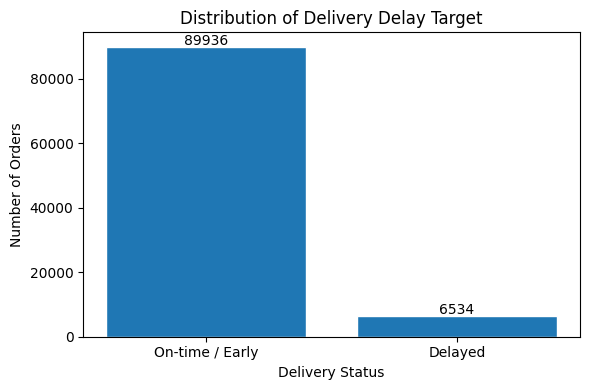

In [39]:
# ============================================================
# 4.1 Target variable distribution
# ============================================================

target_counts = df['is_delayed'].value_counts().sort_index()
target_rates = df['is_delayed'].value_counts(normalize=True).sort_index()

print("Target counts:")
display(target_counts)

print("Target proportions:")
display(target_rates)

plt.figure(figsize=(6, 4))
plt.bar(['On-time / Early', 'Delayed'], target_counts.values, edgecolor='white')
plt.title('Distribution of Delivery Delay Target')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')

for i, v in enumerate(target_counts.values):
    plt.text(i, v + 500, str(v), ha='center')

plt.tight_layout()
plt.show()

The target variable is highly imbalanced: 6,534 orders are delayed, while 89,936 orders are delivered on time or early. Delayed orders account for only 6.77% of the dataset.

Because of this imbalance, accuracy alone may be misleading. Model evaluation should also consider recall, precision, F1-score, confusion matrix, and ROC-AUC.

### 4.2 Delivery Time and Delay Distribution

I examine the distributions of actual delivery duration and delay days. `delivery_days` measures how long delivery took, while `delay_days` compares the actual delivery date with the estimated delivery date. Negative delay values indicate early delivery, while positive values indicate late delivery.

For visualisation, extreme values are clipped in the histograms to make the main distribution easier to read. The original values are kept in the dataset.


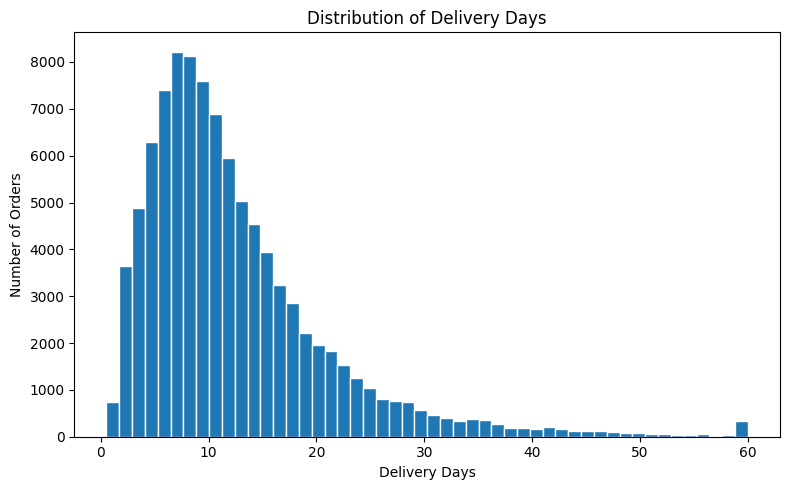

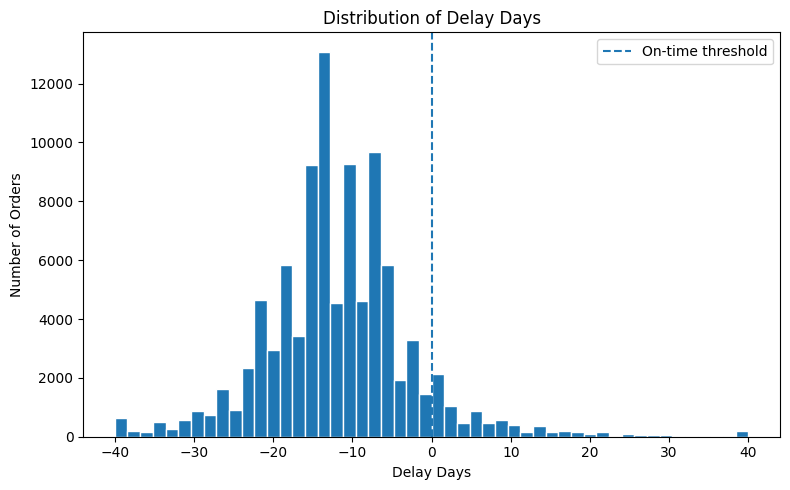

,delivery_days,delay_days,estimated_window
count,96470.00,96470.00,96470.00
mean,12.56,-11.88,24.37
std,9.55,10.18,8.76
min,0.53,-147.00,3.00
25%,6.77,-17.00,19.00
50%,10.22,-12.00,24.00
75%,15.72,-7.00,29.00
max,209.63,188.00,156.00


In [41]:
# ============================================================
# 4.2 Delivery time and delay distribution
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(df['delivery_days'].clip(0, 60), bins=50, edgecolor='white')
plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['delay_days'].clip(-40, 40), bins=50, edgecolor='white')
plt.axvline(0, linestyle='--', label='On-time threshold')
plt.title('Distribution of Delay Days')
plt.xlabel('Delay Days')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

df[['delivery_days', 'delay_days', 'estimated_window']].describe().round(2)

Most orders have negative `delay_days`, meaning they were delivered earlier than the estimated delivery date. This supports the earlier observation that Olist's estimated delivery windows were generally conservative.

The positive tail represents delayed orders, where actual delivery exceeded the estimated delivery date. These cases define the delayed class used in the supervised learning models.


### 4.3 Delay Rate by Purchase Month

I examine whether delivery delay varies by purchase month. Monthly patterns may reflect seasonality, promotional periods, or temporary logistics pressure, and can provide an initial view of time-related variation in delivery performance.

,order_count,delay_rate,avg_delivery_days,avg_delay_days
purchase_month,,,,
1,7819,0.054,13.489,-14.323
2,8208,0.119,15.723,-10.487
3,9549,0.151,14.942,-8.001
4,9101,0.050,11.885,-12.915
5,10294,0.053,10.891,-12.641
6,9231,0.018,9.702,-17.003
7,10028,0.032,9.518,-11.839
8,10544,0.049,8.644,-10.125
9,4151,0.044,11.411,-11.337


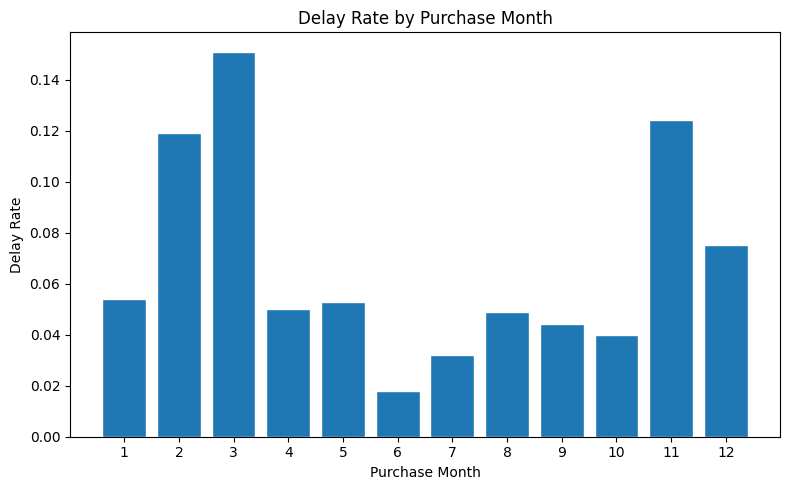

In [ ]:
# ============================================================
# 4.3 Delay rate by purchase month
# ============================================================

monthly_delay = df.groupby('purchase_month').agg(
    order_count=('order_id', 'count'),
    delay_rate=('is_delayed', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean')
).round(3)

display(monthly_delay)

plt.figure(figsize=(8, 5))
plt.bar(monthly_delay.index, monthly_delay['delay_rate'], edgecolor='white')
plt.title('Delay Rate by Purchase Month')
plt.xlabel('Purchase Month')
plt.ylabel('Delay Rate')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Delay rates vary across purchase months, suggesting that delivery performance has a seasonal pattern. March and November show relatively high delay rates, while June shows the lowest delay rate.

The higher delay rate in November may be related to Black Friday demand pressure. This is examined more directly later using the peak-season indicators.

### 4.4 Holiday and peak-season effects

This step compares delay rates across holiday and peak-season indicators. Since public holidays, Black Friday, and Christmas may affect demand and logistics capacity, these variables are examined before being included in modelling.

,value,order_count,delay_rate,avg_delivery_days,avg_delay_days,avg_estimated_window,avg_review_score,feature
0,0,71988,0.072,12.505,-11.820,24.265,4.148,is_holiday_period
1,1,24482,0.056,12.716,-12.041,24.691,4.181,is_holiday_period
2,0,89961,0.063,12.312,-12.050,24.303,4.169,is_peak_season
3,1,6509,0.128,15.966,-9.464,25.342,3.972,is_peak_season
4,0,92215,0.063,12.372,-12.109,24.421,4.170,is_black_friday_period
5,1,4255,0.170,16.600,-6.818,23.329,3.857,is_black_friday_period
6,0,94216,0.068,12.505,-11.814,24.259,4.155,is_christmas_period
7,1,2254,0.047,14.767,-14.459,29.141,4.191,is_christmas_period


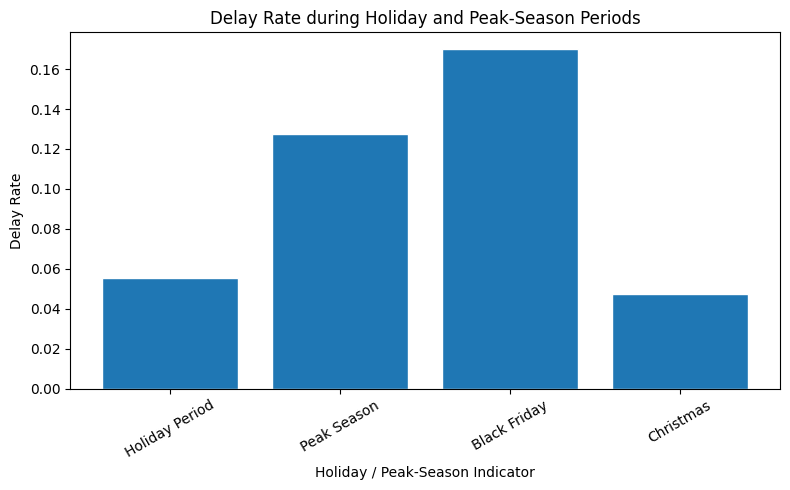

In [42]:
# ============================================================
# 4.4 Holiday and peak-season effects
# ============================================================

holiday_features = [
    'is_holiday_period',
    'is_peak_season',
    'is_black_friday_period',
    'is_christmas_period'
]

holiday_summary = []

for col in holiday_features:
    temp = df.groupby(col).agg(
        order_count=('order_id', 'count'),
        delay_rate=('is_delayed', 'mean'),
        avg_delivery_days=('delivery_days', 'mean'),
        avg_delay_days=('delay_days', 'mean'),
        avg_estimated_window=('estimated_window', 'mean'),
        avg_review_score=('review_score', 'mean')
    ).round(3)

    temp['feature'] = col
    holiday_summary.append(
        temp.reset_index().rename(columns={col: 'value'})
    )

holiday_summary = pd.concat(holiday_summary, ignore_index=True)
display(holiday_summary)

# Plot delay rate when each holiday or peak-season indicator equals 1
holiday_delay_rates = {
    col: df[df[col] == 1]['is_delayed'].mean()
    for col in holiday_features
}

feature_labels = {
    'is_holiday_period': 'Holiday Period',
    'is_peak_season': 'Peak Season',
    'is_black_friday_period': 'Black Friday',
    'is_christmas_period': 'Christmas'
}

plt.figure(figsize=(8, 5))
plt.bar(
    [feature_labels[col] for col in holiday_delay_rates.keys()],
    holiday_delay_rates.values(),
    edgecolor='white'
)

plt.title('Delay Rate during Holiday and Peak-Season Periods')
plt.xlabel('Holiday / Peak-Season Indicator')
plt.ylabel('Delay Rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The calendar-based indicators show different patterns. The Black Friday period has the highest delay rate at 17.0%, compared with the overall delay rate of 6.77%. Peak-season orders also have a higher delay rate of 12.8% and longer average delivery duration.

In contrast, general holiday-period orders and Christmas-period orders do not show higher delay rates. Christmas orders have a longer estimated delivery window, which may explain why their delay rate remains low despite longer delivery duration.

Overall, these results suggest that delivery delays are more strongly associated with demand-surge periods, especially Black Friday, than with public holidays in general.

### 4.5 Cross-State Logistics Effect

The variable `is_cross_state` indicates whether the customer and the representative seller are located in different states. This is used as a simple proxy for logistics distance or route complexity.

I compare same-state and cross-state orders to examine whether cross-state delivery is associated with longer delivery duration, higher freight cost, or higher delay risk.


,order_count,delay_rate,avg_delivery_days,avg_delay_days,avg_estimated_window,avg_freight,avg_review_score
is_cross_state,,,,,,,
Same State,34701,0.045,7.945,-10.333,18.216,15.453,4.263
Cross State,61769,0.080,15.150,-12.743,27.832,26.905,4.096


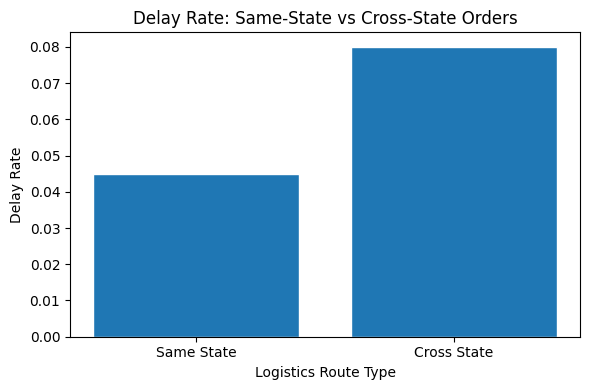

In [43]:
# ============================================================
# 4.5 Cross-state logistics effect
# ============================================================

cross_state_summary = df.groupby('is_cross_state').agg(
    order_count=('order_id', 'count'),
    delay_rate=('is_delayed', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean'),
    avg_estimated_window=('estimated_window', 'mean'),
    avg_freight=('total_freight', 'mean'),
    avg_review_score=('review_score', 'mean')
).round(3)

cross_state_summary.index = cross_state_summary.index.map({
    0: 'Same State',
    1: 'Cross State'
})

display(cross_state_summary)

plt.figure(figsize=(6, 4))
plt.bar(
    cross_state_summary.index,
    cross_state_summary['delay_rate'],
    edgecolor='white'
)

plt.title('Delay Rate: Same-State vs Cross-State Orders')
plt.xlabel('Logistics Route Type')
plt.ylabel('Delay Rate')
plt.tight_layout()
plt.show()

Cross-state orders show clear evidence of greater logistics complexity. They have a higher delay rate than same-state orders, 8.0% compared with 4.5%, and their average delivery duration is much longer, 15.2 days compared with 7.9 days.

Cross-state orders also have higher average freight cost and longer estimated delivery windows. This suggests that Olist appears to account for longer-distance delivery when setting estimated dates. However, the delay rate is still higher for cross-state orders, indicating that cross-state delivery remains a useful risk indicator for delivery-delay prediction.

### 4.6 Review Score and Delivery Delay

I examine the relationship between delivery delay and customer review score. This helps connect logistics performance with customer satisfaction. Since review score is observed after delivery, it is used only for exploratory analysis and is not included as a predictor in the supervised learning models.

,order_count,review_count,avg_review_score,avg_delivery_days,avg_delay_days
is_delayed,,,,,
On-time / Early,89936,89443,4.291,11.004,-13.51
Delayed,6534,6381,2.272,33.950,10.62


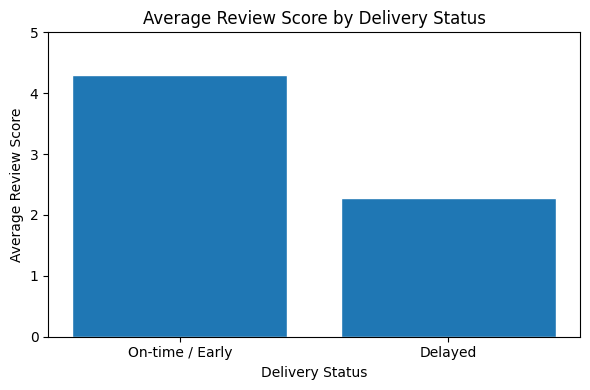

In [44]:
# ============================================================
# 4.6 Review score and delivery delay
# ============================================================

review_by_delay = df.groupby('is_delayed').agg(
    order_count=('order_id', 'count'),
    review_count=('review_score', 'count'),
    avg_review_score=('review_score', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean')
).round(3)

review_by_delay.index = review_by_delay.index.map({
    0: 'On-time / Early',
    1: 'Delayed'
})

display(review_by_delay)

plt.figure(figsize=(6, 4))
plt.bar(
    review_by_delay.index,
    review_by_delay['avg_review_score'],
    edgecolor='white'
)

plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

Delayed orders have much lower review scores than on-time or early orders. The average review score is 2.27 for delayed orders, compared with 4.29 for on-time or early orders.

Delayed orders also have much longer delivery duration, with an average of 34.0 days compared with 11.0 days. This suggests that delivery delay is strongly associated with lower customer satisfaction. However, review score is used only for exploratory analysis and is not included as a predictor, because it is observed after delivery.

### 4.7 Seller Concurrent Load and Delivery Delay

This section examines whether seller-side capacity pressure is associated with delivery delay. `seller_concurrent_load_max` measures how many active orders a seller was already handling when a new order was placed.

If orders with higher seller concurrent load show higher delay rates, this supports the idea that temporary seller workload may be an important operational risk factor beyond static order characteristics.

,seller_load_quartile,order_count,avg_seller_load,delay_rate,avg_delivery_days,avg_delay_days,avg_estimated_window,avg_review_score
0,"(-0.001, 2.0]",32237,0.850,0.058,11.780,-12.611,24.333,4.240
1,"(2.0, 5.0]",16569,3.881,0.059,12.083,-12.217,24.235,4.193
2,"(5.0, 17.0]",24524,10.120,0.065,12.448,-11.759,24.152,4.149
3,"(17.0, 219.0]",23140,43.906,0.090,14.100,-10.731,24.761,4.021


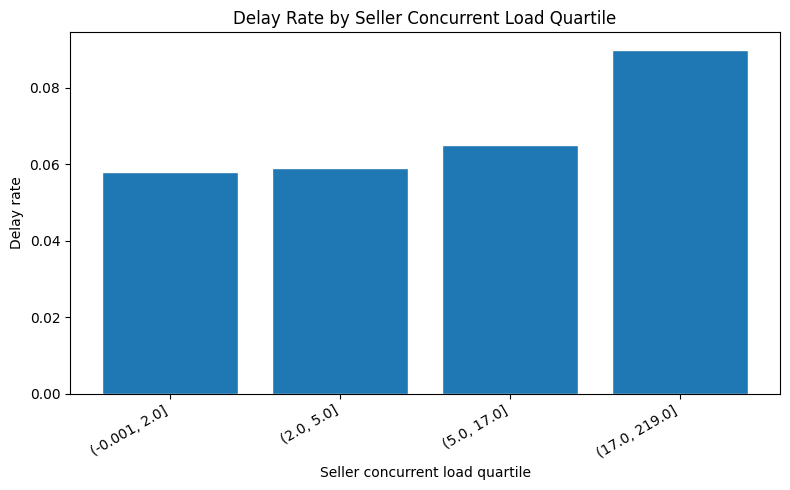

In [45]:
# ============================================================
# 4.7a Delay rate by seller concurrent load quartile
# ============================================================

# Group orders into load quartiles to explore whether delay risk changes
# across different levels of seller-side workload pressure.

df['seller_load_quartile'] = pd.qcut(
    df['seller_concurrent_load_max'],
    q=4,
    duplicates='drop'
)

seller_load_delay = df.groupby(
    'seller_load_quartile',
    observed=True
).agg(
    order_count=('order_id', 'count'),
    avg_seller_load=('seller_concurrent_load_max', 'mean'),
    delay_rate=('is_delayed', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean'),
    avg_estimated_window=('estimated_window', 'mean'),
    avg_review_score=('review_score', 'mean')
).reset_index().round(3)

display(seller_load_delay)

plt.figure(figsize=(8, 5))
plt.bar(
    seller_load_delay['seller_load_quartile'].astype(str),
    seller_load_delay['delay_rate'],
    edgecolor='white'
)

plt.title('Delay Rate by Seller Concurrent Load Quartile')
plt.xlabel('Seller concurrent load quartile')
plt.ylabel('Delay rate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Seller concurrent load shows a clear increasing pattern with delivery delay. Orders in the lowest load group have a delay rate of 5.8%, while orders in the highest load group have a delay rate of 9.0%. The highest-load group also has longer average delivery duration, 14.1 days compared with 11.8 days in the lowest-load group.

This suggests that seller-side workload pressure is associated with higher delivery risk. The pattern supports the use of `seller_concurrent_load_max` as an operational risk indicator beyond static order characteristics such as price, freight, product size, and location.


In [46]:
# ============================================================
# 4.7b Seller load during Black Friday vs normal periods
# ============================================================

# Compare Black Friday with normal periods to examine whether
# demand-surge periods are associated with higher seller workload.

load_by_bf = df.groupby('is_black_friday_period').agg(
    order_count=('order_id', 'count'),
    avg_seller_load=('seller_concurrent_load_max', 'mean'),
    median_seller_load=('seller_concurrent_load_max', 'median'),
    delay_rate=('is_delayed', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean'),
    avg_estimated_window=('estimated_window', 'mean'),
    avg_review_score=('review_score', 'mean')
).round(3)

load_by_bf.index = load_by_bf.index.map({
    0: 'Normal Period',
    1: 'Black Friday Period'
})

print("Seller load comparison: Black Friday vs normal periods")
display(load_by_bf)

Seller load comparison: Black Friday vs normal periods


,order_count,avg_seller_load,median_seller_load,delay_rate,avg_delivery_days,avg_delay_days,avg_estimated_window,avg_review_score
is_black_friday_period,,,,,,,,
Normal Period,92215,13.574,5.0,0.063,12.372,-12.109,24.421,4.170
Black Friday Period,4255,24.478,9.0,0.170,16.600,-6.818,23.329,3.857


Black Friday orders show much higher seller-side workload pressure than normal-period orders. The average seller concurrent load increases from 13.6 to 24.5 active orders, and the median load increases from 5 to 9. At the same time, the delay rate rises from 6.3% to 17.0%.

Black Friday orders also take longer to deliver and receive lower average review scores. This suggests that Black Friday is not only a calendar effect, but also a demand-surge period associated with higher seller workload, longer delivery time, and worse customer experience.

### 4.8 EDA Summary

The exploratory analysis reveals several important logistics patterns. First, the target variable is highly imbalanced. Only 6.77% of delivered orders are classified as delayed, while 93.23% are delivered on time or earlier than the estimated delivery date. This means that delay is a minority event, so supervised learning should not rely on accuracy alone.

Second, most orders are delivered earlier than expected, suggesting that Olist's estimated delivery windows are generally conservative. However, delayed orders are still important because they are associated with much longer delivery duration and substantially lower customer review scores.

Third, logistics route complexity appears to matter. Cross-state orders have a higher delay rate, longer delivery duration, and higher freight cost than same-state orders. This supports the use of cross-state delivery as a simple proxy for logistics complexity.

Fourth, calendar effects are not uniform. General holiday-period orders do not show higher delay rates, while Black Friday orders show a much higher delay rate. This suggests that demand-surge periods may create stronger delivery risk than public holidays in general.

Finally, seller concurrent load is associated with delivery delay. Orders in the highest seller-load group have a higher delay rate and longer delivery duration than orders in lower-load groups. Black Friday orders also show higher seller concurrent load, suggesting that demand surges may increase delay risk partly through seller-side workload pressure.

Overall, the EDA suggests that delivery delay is a relatively rare but business-critical event. The following modelling sections therefore examine both logistics risk profiles through clustering and delayed-order prediction through supervised classification.


##5. Unsupervised Learning: K-Means Clustering

Before building supervised models to predict delivery delay, I apply K-Means clustering to identify natural groups of orders based on logistics characteristics. Clustering answers a different question from supervised learning. Instead of asking whether an order will be delayed, it asks what types of logistics orders exist.

The delay label is not used to form the clusters. After the clusters are created, I compare their delay rates, delivery duration, seller workload, and review scores to understand whether different logistics profiles are associated with different levels of operational risk.

### 5.1 Prepare clustering data

I select numerical variables that describe each order's logistics profile, including freight cost, product weight, product volume, estimated delivery window, cross-state delivery, peak-season period, item count, and seller concurrent load.

The target variable is_delayed is not included in the clustering features because K-Means is an unsupervised learning method. However, I keep is_delayed, delivery_days, delay_days, and review_score in a separate clustering dataset so that I can interpret the outcomes of each cluster after the clusters are formed.

Because K-Means uses Euclidean distance, features must be standardised before clustering. I therefore transform the clustering variables into z-scores before fitting the model.

In [47]:
# ============================================================
# 5.1 Prepare clustering data
# ============================================================

# Select logistics-related features for clustering.
# These variables describe the order profile and are known before the delivery outcome.
cluster_features = [
    'total_freight',
    'product_weight_g',
    'product_volume_cm3',
    'estimated_window',
    'is_cross_state',
    'is_peak_season',
    'item_count',
    'seller_concurrent_load_max'
]

# Keep clustering features and outcome variables for later interpretation.
# Missing values are dropped only for clustering features, not for review_score,
# because review_score is used only for post-cluster interpretation.
df_cluster = df[
    cluster_features + [
        'order_id',
        'is_delayed',
        'delay_days',
        'delivery_days',
        'review_score'
    ]
].dropna(subset=cluster_features).copy()

# Feature matrix for clustering
X_cluster = df_cluster[cluster_features].copy()

# Standardise features using z-score normalisation.
# This is necessary because K-Means is distance-based.
X_cluster_norm = pd.DataFrame(
    preprocessing.scale(X_cluster),
    columns=cluster_features,
    index=X_cluster.index
)

print(f"Clustering data: {X_cluster_norm.shape[0]} orders, {len(cluster_features)} features")

# Check the scaled data
display(X_cluster_norm.describe().round(2))

Clustering data: 96470 orders, 8 features


,total_freight,product_weight_g,product_volume_cm3,estimated_window,is_cross_state,is_peak_season,item_count,seller_concurrent_load_max
count,96470.00,96470.00,96470.00,96470.00,96470.00,96470.00,96470.00,96470.00
mean,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.06,-0.50,-0.57,-2.44,-1.33,-0.27,-0.26,-0.64
25%,-0.41,-0.44,-0.48,-0.61,-1.33,-0.27,-0.26,-0.55
50%,-0.26,-0.34,-0.33,-0.04,0.75,-0.27,-0.26,-0.41
75%,0.06,-0.07,0.08,0.53,0.75,-0.27,-0.26,0.13
max,82.20,38.16,48.39,15.03,0.75,3.72,36.85,9.39


The clustering dataset contains 96,470 orders and 8 logistics-related features. After standardisation, all features have a mean close to 0 and a standard deviation close to 1, which confirms that the data is ready for K-Means clustering. Some variables have large maximum z-scores, suggesting the presence of extreme logistics cases, such as unusually high freight cost, large item count, or high seller concurrent load.

### 5.2 Choose the Number of Clusters Using the Elbow Method

To choose the number of clusters, I use the elbow method. This method calculates the within-cluster sum of squares, also called inertia or total WSS, for different values of `k`.

As `k` increases, WSS decreases because more clusters can fit the data more closely. The aim is to identify a point where the decrease begins to slow down. This point is known as the elbow point and provides a useful guide for selecting the number of clusters.


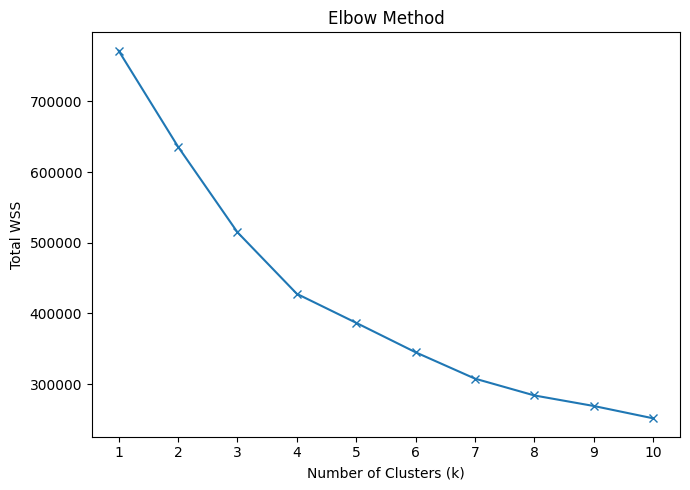

In [48]:
# ============================================================
# 5.2 Choose k using the elbow method
# ============================================================

wss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )
    kmeans.fit(X_cluster_norm)
    wss.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_values, wss, marker='x')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Total WSS')
plt.title('Elbow Method')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

The elbow plot suggests that k = 4 is a reasonable choice because the reduction in WSS becomes smaller after four clusters.

### 5.3 Check Silhouette Scores

To support the elbow method, I also calculate silhouette scores for different values of `k`. The silhouette score measures how well each observation fits within its assigned cluster compared with other clusters. A higher score suggests better-separated clusters.

I use silhouette scores as a supporting check rather than the only criterion, because the final number of clusters should also be interpretable for business analysis.


,k,silhouette_score
0,2,0.5424
1,3,0.3265
2,4,0.3718
3,5,0.3774
4,6,0.3921
5,7,0.3989
6,8,0.3255


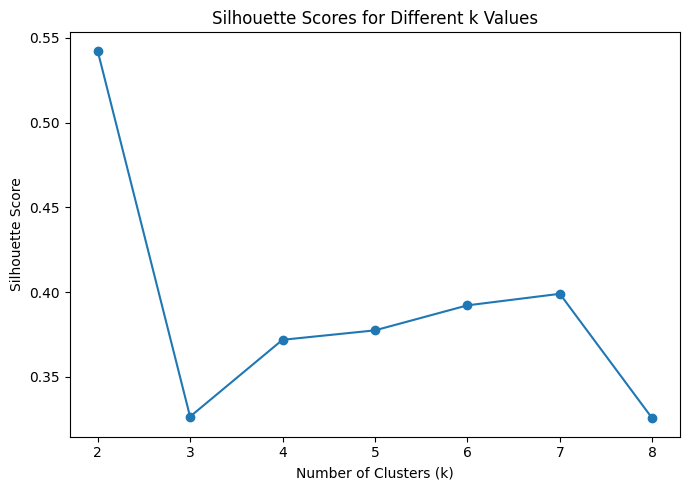

In [49]:
# ============================================================
# 5.3 Check silhouette scores
# ============================================================

from sklearn.metrics import silhouette_score

silhouette_results = []

for k in range(2, 9):
    km = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )

    labels = km.fit_predict(X_cluster_norm)

    # Use a sample for silhouette score to reduce computation time
    sil = silhouette_score(
        X_cluster_norm,
        labels,
        sample_size=10000,
        random_state=0
    )

    silhouette_results.append({
        'k': k,
        'silhouette_score': sil
    })

silhouette_df = pd.DataFrame(silhouette_results)

display(silhouette_df.round(4))

plt.figure(figsize=(7, 5))
plt.plot(
    silhouette_df['k'],
    silhouette_df['silhouette_score'],
    marker='o'
)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k Values')
plt.xticks(silhouette_df['k'])
plt.tight_layout()
plt.show()

Although `k = 2` has the highest silhouette score, it would divide the orders into only two broad groups, which may be too coarse for interpreting different logistics risk profiles. Values such as `k = 6` or `k = 7` also show reasonable silhouette scores, but they would create more fragmented clusters that are harder to interpret for business analysis.

Therefore, I select `k = 4` as a balanced choice. It provides enough detail to distinguish different logistics order profiles while keeping the clusters interpretable for later comparison of delay rates, delivery duration, seller workload, and review scores.


### 5.4 Fit the Final K-Means Model

Based on the elbow method, silhouette scores, and business interpretability, I choose `k = 4` and fit the final K-Means model. The cluster label is added back to the clustering dataset, where each cluster represents a different logistics order profile.


In [50]:
# ============================================================
# 5.4 Fit final K-Means model
# ============================================================

# Choose k based on the elbow method, silhouette scores, and interpretability
CHOSEN_K = 4

kmeans_final = KMeans(
    n_clusters=CHOSEN_K,
    random_state=0,
    n_init=10
)

df_cluster['cluster'] = kmeans_final.fit_predict(X_cluster_norm)

# Display cluster size and proportion
cluster_sizes = df_cluster['cluster'].value_counts().sort_index()
cluster_distribution = pd.DataFrame({
    'order_count': cluster_sizes,
    'proportion': cluster_sizes / len(df_cluster)
})

display(cluster_distribution.round(3))

,order_count,proportion
cluster,,
0,30701,0.318
1,4848,0.050
2,54551,0.565
3,6370,0.066


The four clusters are unevenly distributed, with Cluster 2 representing the largest group of orders and Cluster 1 representing the smallest group. This is acceptable because K-Means is used here to identify different logistics order profiles rather than to create equally sized groups.

The smaller clusters may capture more specialised or higher-risk order types, while the larger clusters likely represent more common logistics patterns. The next step is therefore to examine the feature profiles and delivery outcomes of each cluster.

### 5.5 Interpret Cluster Centroids Using Parallel Coordinates

To understand how the clusters differ, I visualise the standardised cluster centroids using a parallel coordinates plot. Each line represents one cluster, and each axis represents one logistics feature used in the clustering model.

Because the centroid values are standardised, values above zero mean that a cluster is above the dataset average for that feature, while values below zero mean that it is below average. This helps translate the K-Means output into interpretable logistics order profiles.

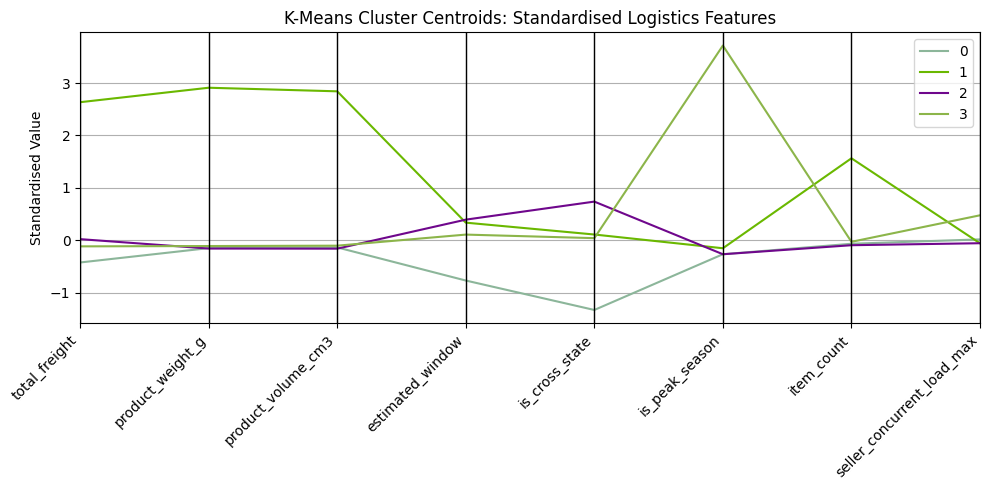

,total_freight,product_weight_g,product_volume_cm3,estimated_window,is_cross_state,is_peak_season,item_count,seller_concurrent_load_max,Cluster
0,-0.43,-0.15,-0.14,-0.77,-1.33,-0.27,-0.07,0.01,0
1,2.64,2.91,2.84,0.33,0.11,-0.15,1.56,-0.06,1
2,0.02,-0.16,-0.16,0.39,0.74,-0.27,-0.10,-0.06,2
3,-0.12,-0.11,-0.11,0.11,0.04,3.72,-0.03,0.47,3


In [51]:
# ============================================================
# 5.5 Interpret cluster centroids using parallel coordinates
# ============================================================

from pandas.plotting import parallel_coordinates

# Create a DataFrame of standardised cluster centroids
centroids = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=cluster_features
)

centroids['Cluster'] = centroids.index.astype(str)

# Visualise standardised cluster centroids
plt.figure(figsize=(10, 5))
parallel_coordinates(
    centroids,
    'Cluster'
)

plt.title('K-Means Cluster Centroids: Standardised Logistics Features')
plt.ylabel('Standardised Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(centroids.round(2))

The centroid plot shows four interpretable logistics profiles. Cluster 0 is characterised by same-state delivery, lower freight cost, and shorter estimated delivery windows, suggesting a relatively simple local-delivery profile.

Cluster 1 has much higher freight cost, product weight, product volume, and item count. This suggests a bulky or heavy-order profile, where logistics complexity is mainly driven by product characteristics.

Cluster 2 is strongly associated with cross-state delivery and longer estimated delivery windows. This represents a cross-state logistics profile, where delivery is likely to involve longer-distance transportation.

Cluster 3 is mainly defined by the peak-season indicator and also has above-average seller concurrent load. This suggests a peak-season workload-pressure profile, where demand-surge periods may combine with higher seller-side capacity pressure.


### 5.6 Interpret Clusters Using Original-Scale Profiles

The parallel coordinates plot shows standardised centroid values, which are useful for comparing clusters but less intuitive in business terms. To make the clusters easier to interpret, I calculate the average original feature values for each cluster.

For binary variables such as `is_cross_state` and `is_peak_season`, the mean represents the proportion of orders in that cluster with the corresponding characteristic. This helps describe each cluster as a meaningful logistics order profile.


In [52]:
# ============================================================
# 5.6 Cluster profiles using original-scale feature values
# ============================================================

cluster_profile = df_cluster.groupby('cluster').agg(
    order_count=('order_id', 'count'),
    total_freight=('total_freight', 'mean'),
    product_weight_g=('product_weight_g', 'mean'),
    product_volume_cm3=('product_volume_cm3', 'mean'),
    estimated_window=('estimated_window', 'mean'),
    cross_state_share=('is_cross_state', 'mean'),
    peak_season_share=('is_peak_season', 'mean'),
    item_count=('item_count', 'mean'),
    seller_concurrent_load_max=('seller_concurrent_load_max', 'mean')
).round(2)

cluster_profile['proportion'] = (
    cluster_profile['order_count'] / len(df_cluster)
).round(3)

# Move proportion next to order_count
cluster_profile = cluster_profile[
    [
        'order_count',
        'proportion',
        'total_freight',
        'product_weight_g',
        'product_volume_cm3',
        'estimated_window',
        'cross_state_share',
        'peak_season_share',
        'item_count',
        'seller_concurrent_load_max'
    ]
]

print("Cluster profiles: average feature values in original scale")
display(cluster_profile)

Cluster profiles: average feature values in original scale


,order_count,proportion,total_freight,product_weight_g,product_volume_cm3,estimated_window,cross_state_share,peak_season_share,item_count,seller_concurrent_load_max
cluster,,,,,,,,,,
0,30701,0.318,13.59,1661.23,13152.50,17.62,0.00,0.00,1.11,14.38
1,4848,0.050,79.61,16275.42,103029.97,27.30,0.69,0.03,1.98,12.74
2,54551,0.565,23.21,1622.93,12434.14,27.81,0.99,0.00,1.09,12.78
3,6370,0.066,20.23,1850.26,14153.19,25.30,0.66,1.00,1.13,24.43


The original-scale profiles make the clusters easier to interpret as logistics order types. Cluster 0 represents local low-complexity orders, with same-state delivery, low freight cost, and shorter estimated delivery windows. Cluster 1 represents bulky high-freight orders, with much higher product weight, product volume, freight cost, and item count.

Cluster 2 represents cross-state standard orders. It is the largest cluster and has a very high cross-state share, but its product size and item count are relatively low. Cluster 3 represents peak-season workload-pressure orders, with all orders occurring in peak-season periods and the highest average seller concurrent load.

These profiles suggest that logistics risk can arise from different sources, including route complexity, product bulkiness, and temporary peak-season seller workload.

In [53]:
# ============================================================
# 5.6a Add descriptive cluster names
# ============================================================

# Add descriptive cluster names based on the original-scale cluster profiles.
# The names are based on logistics characteristics, not on the delay outcome.

cluster_names = {
    0: 'Local low-complexity orders',
    1: 'Heavy bulky high-freight orders',
    2: 'Standard cross-state orders',
    3: 'Peak-season workload-pressure orders'
}

df_cluster['cluster_name'] = df_cluster['cluster'].map(cluster_names)

display(
    df_cluster[['cluster', 'cluster_name']]
    .drop_duplicates()
    .sort_values('cluster')
)

,cluster,cluster_name
0,0,Local low-complexity orders
9,1,Heavy bulky high-freight orders
1,2,Standard cross-state orders
16,3,Peak-season workload-pressure orders


### 5.7 Compare Cluster Outcomes

After forming clusters based only on logistics characteristics, I compare the delivery outcomes of each cluster. This step does not affect the clustering process. Instead, it helps examine whether different logistics order profiles are associated with different delay rates, delivery durations, seller workload levels, and review scores.


In [54]:
# ============================================================
# 5.7 Compare cluster outcomes
# ============================================================

cluster_outcomes_named = df_cluster.groupby(
    ['cluster', 'cluster_name']
).agg(
    order_count=('order_id', 'count'),
    delay_rate=('is_delayed', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean'),
    avg_estimated_window=('estimated_window', 'mean'),
    avg_seller_load=('seller_concurrent_load_max', 'mean'),
    avg_review_score=('review_score', 'mean')
).round(3)

display(cluster_outcomes_named)

,,order_count,delay_rate,avg_delivery_days,avg_delay_days,avg_estimated_window,avg_seller_load,avg_review_score
cluster,cluster_name,,,,,,,
0,Local low-complexity orders,30701,0.044,7.636,-10.044,17.618,14.379,4.285
1,Heavy bulky high-freight orders,4848,0.080,14.923,-12.431,27.302,12.739,3.786
2,Standard cross-state orders,54551,0.073,14.726,-13.138,27.805,12.778,4.137
3,Peak-season workload-pressure orders,6370,0.127,15.916,-9.476,25.304,24.425,3.983


### 5.8 Visualise Cluster-Level Delay Risk

To make the cluster outcomes easier to compare, I visualise the delay rate for each named cluster profile. This shows which logistics profiles are associated with higher delivery risk.

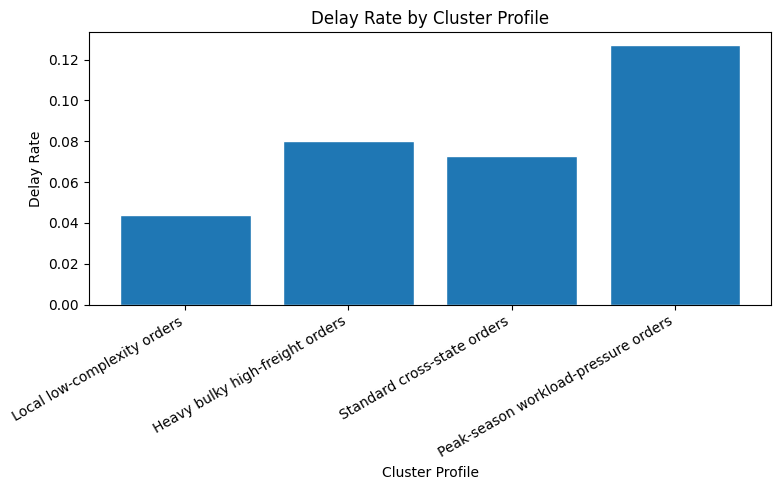

In [55]:
# ============================================================
# 5.8 Visualise cluster-level delay risk
# ============================================================

cluster_plot = cluster_outcomes_named.reset_index()

plt.figure(figsize=(8, 5))
plt.bar(
    cluster_plot['cluster_name'],
    cluster_plot['delay_rate'],
    edgecolor='white'
)

plt.title('Delay Rate by Cluster Profile')
plt.xlabel('Cluster Profile')
plt.ylabel('Delay Rate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 5.9 Add Cluster Labels to the Main Dataframe

To examine whether the logistics risk profiles identified by clustering can improve supervised delay prediction, I merge the cluster labels back into the main analytical dataframe. Cluster membership is then encoded as dummy variables so that it can be used as a categorical predictor alongside other order-level features.

Because the clustering features overlap with some supervised model features, such as freight cost, product weight, estimated delivery window, and seller concurrent load, the cluster dummy variables may partially capture information that is already represented by the raw features. This is acknowledged, and the later model comparison helps assess whether the cluster profiles add useful predictive information.


In [59]:
# ============================================================
# 5.9 Add cluster labels to the main dataframe
# ============================================================

# Merge unsupervised logistics profiles back into the main dataframe
cluster_labels = df_cluster[
    [
        'order_id',
        'cluster',
        'cluster_name'
    ]
].copy()

# Remove existing cluster-related columns before merging
# This prevents duplicate columns if the notebook is re-run.
cols_to_drop = [
    col for col in df.columns
    if col == 'cluster'
    or col == 'cluster_name'
    or col.startswith('cluster_')
]

df = df.drop(columns=cols_to_drop, errors='ignore')

df = df.merge(
    cluster_labels,
    on='order_id',
    how='left'
)

# Convert cluster labels into dummy variables.
# With k = 4 and drop_first=True, this creates 3 dummy variables.
cluster_dummies = pd.get_dummies(
    df['cluster'],
    prefix='cluster',
    drop_first=True
).astype(int)

df = pd.concat(
    [
        df,
        cluster_dummies
    ],
    axis=1
)

# Store dummy-variable names for later modelling
cluster_dummy_features = cluster_dummies.columns.tolist()

print("Cluster labels merged into main dataframe.")
print("Cluster dummy variables created:")
print(cluster_dummy_features)

print(f"Orders with cluster labels: {df['cluster'].notna().sum()}")
print(f"Orders without cluster labels: {df['cluster'].isna().sum()}")

display(
    df[
        [
            'order_id',
            'cluster',
            'cluster_name'
        ] + cluster_dummy_features
    ].head()
)

Cluster labels merged into main dataframe.
Cluster dummy variables created:
['cluster_1', 'cluster_2', 'cluster_3']
Orders with cluster labels: 96470
Orders without cluster labels: 0


,order_id,cluster,cluster_name,cluster_1,cluster_2,cluster_3
0,e481f51cbdc54678b7cc49136f2d6af7,0,Local low-complexity orders,0,0,0
1,53cdb2fc8bc7dce0b6741e2150273451,2,Standard cross-state orders,0,1,0
2,47770eb9100c2d0c44946d9cf07ec65d,2,Standard cross-state orders,0,1,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2,Standard cross-state orders,0,1,0
4,ad21c59c0840e6cb83a9ceb5573f8159,0,Local low-complexity orders,0,0,0


Adding cluster labels to the main dataframe allows the unsupervised logistics profiles to be used in the supervised prediction stage. The purpose is not to assume that the clusters are automatically useful, but to test whether cluster membership adds predictive value beyond the original order-level features.

If models including cluster dummy variables perform better than models without them, this suggests that the cluster profiles capture useful combined logistics patterns. If the improvement is limited, the clusters are still useful for interpretation because they summarise different business-relevant order types, such as local low-complexity orders, bulky high-freight orders, cross-state orders, and peak-season workload-pressure orders.

Therefore, the cluster variables serve two purposes: they provide interpretable logistics segments, and they allow the later models to test whether these segments improve delay-risk prediction.

### 5.10 Clustering Summary

The K-Means analysis identifies four interpretable logistics order profiles: local low-complexity orders, heavy bulky high-freight orders, standard cross-state orders, and peak-season workload-pressure orders.

These clusters show that delivery risk can come from different sources, including product bulkiness, cross-state logistics complexity, and temporary peak-season seller workload. The cluster labels are therefore kept for the supervised modelling stage to test whether these logistics profiles add predictive value for delivery-delay prediction.


## 6. Supervised Learning: Delivery Delay Classification

This section builds supervised learning models to predict whether an order will be delayed. The target variable is `is_delayed`, where 1 indicates delayed delivery and 0 indicates on-time or early delivery.

The prediction uses only features that are available before the delivery outcome is known, such as price, freight cost, product characteristics, estimated delivery window, customer-seller location relationship, purchase month, holiday or peak-season indicators, seller concurrent load, and cluster membership. Post-delivery variables such as `delivery_days`, `delay_days`, and `review_score` are excluded to avoid data leakage.

Because delayed orders account for only a small proportion of the dataset, this is an imbalanced classification problem. Therefore, model performance is evaluated using not only accuracy, but also precision, recall, F1-score, confusion matrix, and ROC-AUC, with particular attention to the delayed class.




### 6.1 Define Modelling Features

I define the modelling features using only information available before the delivery outcome is known. The features are organised into progressive sets so that the contribution of holiday indicators, seller concurrent load, and cluster membership can be compared in later models.

In [60]:
# ============================================================
# 6.1 Define modelling features
# ============================================================

# Base order and logistics features
features_base = [
    'total_price',
    'total_freight',
    'product_weight_g',
    'product_volume_cm3',
    'estimated_window',
    'is_cross_state',
    'item_count',
    'purchase_month'
]

# Holiday and peak-season indicators
features_holiday = [
    'is_holiday_period',
    'is_peak_season',
    'is_black_friday_period',
    'is_christmas_period'
]

# Seller concurrent load captures dynamic seller-side workload pressure
features_seller_load = [
    'seller_concurrent_load_max'
]

# Cluster dummies represent unsupervised logistics order profiles
# Created in Section 5.9
cluster_dummy_features = [
    col for col in df.columns
    if col.startswith('cluster_') and col.split('_')[-1].isdigit()
]

# Progressive feature sets
features_set_A = features_base

features_set_B = (
    features_base +
    features_holiday
)

features_set_C = (
    features_base +
    features_holiday +
    features_seller_load
)

features_set_D = (
    features_base +
    features_holiday +
    features_seller_load +
    cluster_dummy_features
)

# Use the full feature set for the main supervised models
features_all = features_set_D

# Prepare modelling dataset
df_model = df[
    features_all + ['is_delayed']
].dropna().copy()

X = df_model[features_all]
y = df_model['is_delayed']

print(f"Classification data: {X.shape[0]} orders, {X.shape[1]} features")
print(f"Target: {y.mean():.2%} delayed, {1 - y.mean():.2%} on-time / early")

print(f"\nFeature set A (base):                 {len(features_set_A)} features")
print(f"Feature set B (+ holiday):            {len(features_set_B)} features")
print(f"Feature set C (+ seller load):        {len(features_set_C)} features")
print(f"Feature set D (+ cluster profiles):   {len(features_set_D)} features")

print("\nCluster dummy features:")
print(cluster_dummy_features)

Classification data: 96470 orders, 16 features
Target: 6.77% delayed, 93.23% on-time / early

Feature set A (base):                 8 features
Feature set B (+ holiday):            12 features
Feature set C (+ seller load):        13 features
Feature set D (+ cluster profiles):   16 features

Cluster dummy features:
['cluster_1', 'cluster_2', 'cluster_3']


### 6.2 Train-Test Split and Scaling

I split the data into training and test sets using an 80/20 split. Because the target variable is imbalanced, I use stratification to keep the delayed-order proportion similar in both sets.

Continuous features are standardised for Logistic Regression because it is scale-sensitive. Tree-based models, including Decision Tree, Random Forest, and XGBoost, are trained on the original unscaled data because they are not sensitive to feature scaling in the same way.


In [61]:
# ============================================================
# 6.2 Train-test split and scaling
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} orders, {y_train.mean():.2%} delayed")
print(f"Test:  {X_test.shape[0]} orders, {y_test.mean():.2%} delayed")

# Scale data for Logistic Regression only
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=features_all,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=features_all,
    index=X_test.index
)

print("Scaled data prepared for Logistic Regression.")

Train: 77176 orders, 6.77% delayed
Test:  19294 orders, 6.77% delayed
Scaled data prepared for Logistic Regression.


### 6.3 Logistic Regression

Logistic Regression is used as an interpretable baseline model. Since the target variable is imbalanced, I use `class_weight='balanced'` to give more weight to delayed orders during training. This helps the model pay more attention to the minority delayed class, although it may reduce overall accuracy or precision for the majority class.


In [62]:
# ============================================================
# 6.3 Logistic Regression
# ============================================================

logit = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

logit.fit(X_train_scaled, y_train)

y_pred_logit = logit.predict(X_test_scaled)
y_prob_logit = logit.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logit):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_prob_logit):.4f}")
print()

print(classification_report(
    y_test,
    y_pred_logit,
    target_names=['On-time / Early', 'Delayed'],
    zero_division=0
))

conf_matrix_logit = pd.DataFrame(
    confusion_matrix(y_test, y_pred_logit),
    index=['Actual On-time / Early', 'Actual Delayed'],
    columns=['Predicted On-time / Early', 'Predicted Delayed']
)

print("Confusion Matrix:")
display(conf_matrix_logit)

Logistic Regression Results
Accuracy: 0.6337
ROC AUC:  0.6858

                 precision    recall  f1-score   support

On-time / Early       0.96      0.63      0.76     17987
        Delayed       0.11      0.62      0.19      1307

       accuracy                           0.63     19294
      macro avg       0.53      0.63      0.48     19294
   weighted avg       0.90      0.63      0.72     19294

Confusion Matrix:


,Predicted On-time / Early,Predicted Delayed
Actual On-time / Early,11411,6576
Actual Delayed,492,815


### 6.4 Tuned Decision Tree Using GridSearchCV

Decision Tree is used as an interpretable tree-based model that can capture non-linear relationships and feature interactions without requiring feature scaling. To avoid choosing tree parameters manually, I tune the model using GridSearchCV.

Since delayed orders are the minority class, I use F1-score as the selection criterion rather than accuracy. This helps the tuning process focus more on identifying delayed orders while still considering precision.


In [65]:
# ============================================================
# 6.4 Tuned Decision Tree using GridSearchCV
# ============================================================

param_grid = {
    'max_depth': [3, 5, 8, 10, 15],
    'min_samples_split': [20, 50, 100, 200],
    'min_samples_leaf': [50, 100, 200],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best CV F1 score: {grid_search.best_score_:.4f}")
print("Best parameters:")
print(grid_search.best_params_)

best_tree = grid_search.best_estimator_

y_pred_tree = best_tree.predict(X_test)
y_prob_tree = best_tree.predict_proba(X_test)[:, 1]

print("\nBest Decision Tree Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_prob_tree):.4f}")
print()

print(classification_report(
    y_test,
    y_pred_tree,
    target_names=['On-time / Early', 'Delayed'],
    zero_division=0
))

conf_matrix_tree = pd.DataFrame(
    confusion_matrix(y_test, y_pred_tree),
    index=['Actual On-time / Early', 'Actual Delayed'],
    columns=['Predicted On-time / Early', 'Predicted Delayed']
)

print("Confusion Matrix:")
display(conf_matrix_tree)

Best CV F1 score: 0.2347
Best parameters:
{'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 200, 'min_samples_split': 20}

Best Decision Tree Results
Accuracy: 0.7160
ROC AUC:  0.7307

                 precision    recall  f1-score   support

On-time / Early       0.96      0.72      0.83     17987
        Delayed       0.14      0.63      0.23      1307

       accuracy                           0.72     19294
      macro avg       0.55      0.68      0.53     19294
   weighted avg       0.91      0.72      0.79     19294

Confusion Matrix:


,Predicted On-time / Early,Predicted Delayed
Actual On-time / Early,12989,4998
Actual Delayed,481,826


### 6.5 Random Forest

Random Forest is used as a tree-based model that can capture non-linear relationships and interactions between features. Unlike Logistic Regression, it does not require scaled input features, so the model is trained on the original feature values.

Because delayed orders are the minority class, I use class balancing to give more weight to delayed orders during training.


In [64]:
# ============================================================
# 6.5 Random Forest
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}")
print()

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['On-time / Early', 'Delayed'],
    zero_division=0
))

conf_matrix_rf = pd.DataFrame(
    confusion_matrix(y_test, y_pred_rf),
    index=['Actual On-time / Early', 'Actual Delayed'],
    columns=['Predicted On-time / Early', 'Predicted Delayed']
)

print("Confusion Matrix:")
display(conf_matrix_rf)

Random Forest Results
Accuracy: 0.7902
ROC AUC:  0.7493

                 precision    recall  f1-score   support

On-time / Early       0.96      0.81      0.88     17987
        Delayed       0.17      0.55      0.26      1307

       accuracy                           0.79     19294
      macro avg       0.57      0.68      0.57     19294
   weighted avg       0.91      0.79      0.84     19294

Confusion Matrix:


,Predicted On-time / Early,Predicted Delayed
Actual On-time / Early,14526,3461
Actual Delayed,586,721


### 6.6 XGBoost

XGBoost is used as a strong gradient boosting benchmark for tabular classification. It can capture non-linear relationships and interactions between features while combining multiple weak learners into a stronger predictive model.

Since the target variable is imbalanced, `scale_pos_weight` is set to the ratio of on-time to delayed orders. This gives more weight to the minority delayed class during training.


In [66]:
# ============================================================
# 6.6 XGBoost
# ============================================================

# Try importing XGBoost first, then install it if needed
try:
    import xgboost as xgb
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        'xgboost',
        '-q'
    ])

    import xgboost as xgb

from sklearn.metrics import average_precision_score

# Calculate scale_pos_weight for imbalanced classification
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
scale_pos_weight = n_negative / n_positive

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR AUC:   {average_precision_score(y_test, y_prob_xgb):.4f}")
print()

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=['On-time / Early', 'Delayed'],
    zero_division=0
))

conf_matrix_xgb = pd.DataFrame(
    confusion_matrix(y_test, y_pred_xgb),
    index=['Actual On-time / Early', 'Actual Delayed'],
    columns=['Predicted On-time / Early', 'Predicted Delayed']
)

print("Confusion Matrix:")
display(conf_matrix_xgb)

XGBoost Results
Accuracy: 0.7276
ROC AUC:  0.7643
PR AUC:   0.2179

                 precision    recall  f1-score   support

On-time / Early       0.97      0.73      0.83     17987
        Delayed       0.15      0.67      0.25      1307

       accuracy                           0.73     19294
      macro avg       0.56      0.70      0.54     19294
   weighted avg       0.91      0.73      0.79     19294

Confusion Matrix:


,Predicted On-time / Early,Predicted Delayed
Actual On-time / Early,13169,4818
Actual Delayed,437,870


### 6.7 ROC Curve Comparison

The ROC curve compares how well each model distinguishes delayed from non-delayed orders across different probability thresholds. ROC-AUC is useful because it evaluates the model's ranking ability rather than relying on one fixed classification threshold.

However, because delayed orders are the minority class, ROC-AUC should be interpreted together with delayed-class precision, recall, F1-score, and PR-AUC in the later model performance summary.


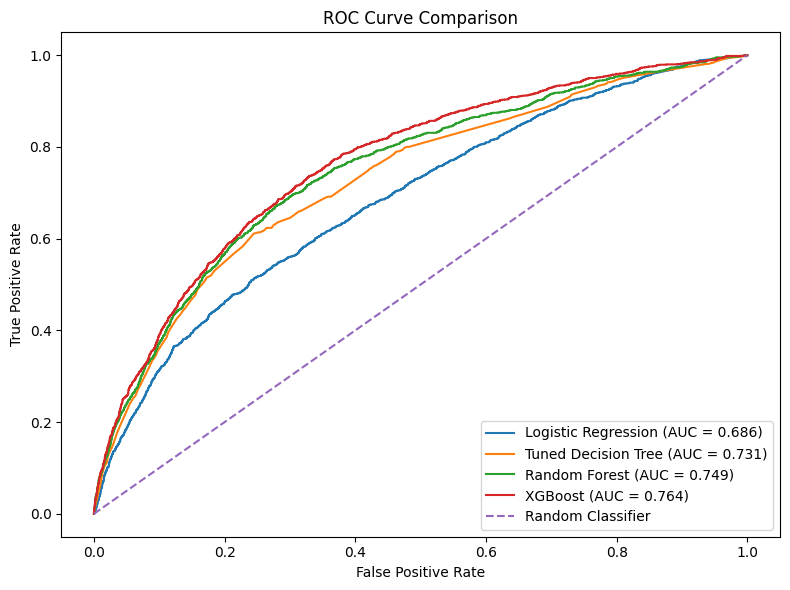

,Model,ROC_AUC
3,XGBoost,0.7643
2,Random Forest,0.7493
1,Tuned Decision Tree,0.7307
0,Logistic Regression,0.6858


In [67]:
# ============================================================
# 6.7 ROC curve comparison
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

model_probabilities = {
    'Logistic Regression': y_prob_logit,
    'Tuned Decision Tree': y_prob_tree,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb
}

roc_auc_results = []

plt.figure(figsize=(8, 6))

for model_name, y_prob_model in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob_model)
    auc_score = roc_auc_score(y_test, y_prob_model)

    roc_auc_results.append({
        'Model': model_name,
        'ROC_AUC': auc_score
    })

    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC = {auc_score:.3f})'
    )

# Random classifier benchmark
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

roc_auc_df = pd.DataFrame(roc_auc_results).sort_values(
    by='ROC_AUC',
    ascending=False
).round(4)

display(roc_auc_df)

### 6.8 Model Performance Summary
This section summarises the performance of all supervised classification models using the same test set. The models include Logistic Regression, Tuned Decision Tree, Random Forest, and XGBoost.

Because delayed orders are the minority class, accuracy alone is not a reliable evaluation metric. A model may achieve high accuracy by predicting most orders as on-time or early, while still failing to identify delayed orders. Therefore, I compare the models using ROC-AUC, PR-AUC, delayed-class precision, delayed-class recall, delayed-class F1-score, and confusion-matrix components.

In this project, the models are interpreted as early-warning tools for potential delivery delays. From this perspective, delayed-class recall is especially important because missing delayed orders would reduce the practical value of the prediction system. However, precision and F1-score are also considered because too many false alarms may create unnecessary operational interventions.

In [70]:
# ============================================================
# 6.8 Model performance summary
# ============================================================
# Summarise the performance of all supervised models on the same test set.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

models_to_compare = {
    'Logistic Regression': {
        'y_pred': y_pred_logit,
        'y_prob': y_prob_logit
    },
    'Tuned Decision Tree': {
        'y_pred': y_pred_tree,
        'y_prob': y_prob_tree
    },
    'Random Forest': {
        'y_pred': y_pred_rf,
        'y_prob': y_prob_rf
    },
    'XGBoost': {
        'y_pred': y_pred_xgb,
        'y_prob': y_prob_xgb
    }
}

performance_results = []

for model_name, outputs in models_to_compare.items():
    y_pred_model = outputs['y_pred']
    y_prob_model = outputs['y_prob']

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_model).ravel()

    performance_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred_model),
        'ROC_AUC': roc_auc_score(y_test, y_prob_model),
        'PR_AUC': average_precision_score(y_test, y_prob_model),
        'Delayed_Precision': precision_score(y_test, y_pred_model, zero_division=0),
        'Delayed_Recall': recall_score(y_test, y_pred_model, zero_division=0),
        'Delayed_F1': f1_score(y_test, y_pred_model, zero_division=0),
        'True_Delayed': tp,
        'Missed_Delayed': fn,
        'False_Alarms': fp,
        'Correct_On_Time': tn
    })

performance_summary = pd.DataFrame(performance_results)

performance_summary = performance_summary.sort_values(
    by='ROC_AUC',
    ascending=False
).reset_index(drop=True)

display(performance_summary.round(4))

,Model,Accuracy,ROC_AUC,PR_AUC,Delayed_Precision,Delayed_Recall,Delayed_F1,True_Delayed,Missed_Delayed,False_Alarms,Correct_On_Time
0,XGBoost,0.7276,0.7643,0.2179,0.1530,0.6656,0.2487,870,437,4818,13169
1,Random Forest,0.7902,0.7493,0.2074,0.1724,0.5516,0.2627,721,586,3461,14526
2,Tuned Decision Tree,0.7160,0.7307,0.1816,0.1418,0.6320,0.2317,826,481,4998,12989
3,Logistic Regression,0.6337,0.6858,0.1488,0.1103,0.6236,0.1874,815,492,6576,11411


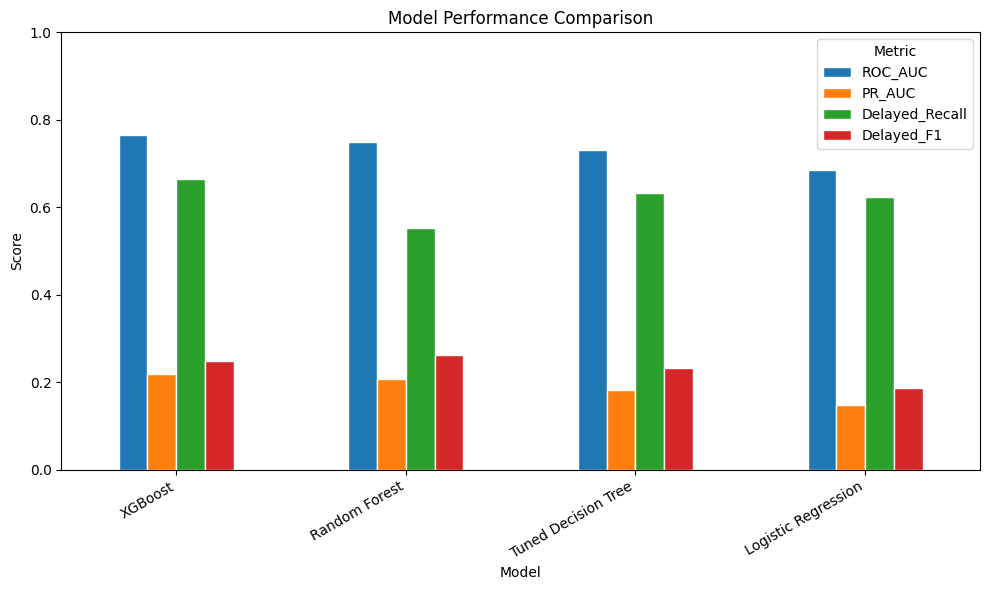

In [71]:
# ============================================================
# Visualise model performance summary
# ============================================================
# Compare models on both overall ranking ability and delayed-class detection.

metrics_to_plot = [
    'ROC_AUC',
    'PR_AUC',
    'Delayed_Recall',
    'Delayed_F1'
]

performance_plot = performance_summary.set_index('Model')[metrics_to_plot]

ax = performance_plot.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='white'
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

XGBoost achieved the strongest overall performance, with the highest ROC-AUC, PR-AUC, and delayed-class recall. This means it was best at identifying potentially delayed orders, although it also produced more false alarms than Random Forest.

Random Forest had the highest accuracy, precision, and F1-score, suggesting a more balanced but more conservative prediction pattern. Overall, XGBoost is more suitable if the priority is to detect as many delayed orders as possible, while Random Forest is preferable if reducing false alarms is more important.

### 6.9 Progressive Feature Set Comparison

This section compares Random Forest models trained on progressively richer feature sets. The purpose is to examine whether additional feature groups improve delay prediction beyond the base order-level variables.

- **Set A**: Base order-level features only
- **Set B**: Base features + holiday and peak-season indicators
- **Set C**: Base + holiday features + seller concurrent load
- **Set D**: Base + holiday features + seller concurrent load + cluster profiles

The same model settings are used across all feature sets so that performance differences mainly reflect the added feature groups rather than changes in model configuration.

In [72]:
# ============================================================
# 6.9 Progressive feature set comparison
# ============================================================
# Compare progressively richer feature sets using the same Random Forest settings.

from sklearn.metrics import average_precision_score

feature_sets = {
    'A: Base only': features_set_A,
    'B: + Holiday': features_set_B,
    'C: + Seller load': features_set_C,
    'D: + Cluster profiles': features_set_D
}

progressive_results = []

for set_name, feature_list in feature_sets.items():

    rf_temp = RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )

    rf_temp.fit(X_train[feature_list], y_train)

    y_pred_temp = rf_temp.predict(X_test[feature_list])
    y_prob_temp = rf_temp.predict_proba(X_test[feature_list])[:, 1]

    progressive_results.append({
        'Feature_Set': set_name,
        'N_Features': len(feature_list),
        'Accuracy': accuracy_score(y_test, y_pred_temp),
        'ROC_AUC': roc_auc_score(y_test, y_prob_temp),
        'PR_AUC': average_precision_score(y_test, y_prob_temp),
        'Delayed_Precision': precision_score(y_test, y_pred_temp, zero_division=0),
        'Delayed_Recall': recall_score(y_test, y_pred_temp, zero_division=0),
        'Delayed_F1': f1_score(y_test, y_pred_temp, zero_division=0)
    })

progressive_results_df = pd.DataFrame(progressive_results)

display(progressive_results_df.round(4))

,Feature_Set,N_Features,Accuracy,ROC_AUC,PR_AUC,Delayed_Precision,Delayed_Recall,Delayed_F1
0,A: Base only,8,0.7654,0.7395,0.1850,0.1575,0.5662,0.2464
1,B: + Holiday,12,0.7846,0.7463,0.1924,0.1684,0.5532,0.2582
2,C: + Seller load,13,0.7857,0.7487,0.2042,0.1709,0.5616,0.2620
3,D: + Cluster profiles,16,0.7902,0.7493,0.2074,0.1724,0.5516,0.2627


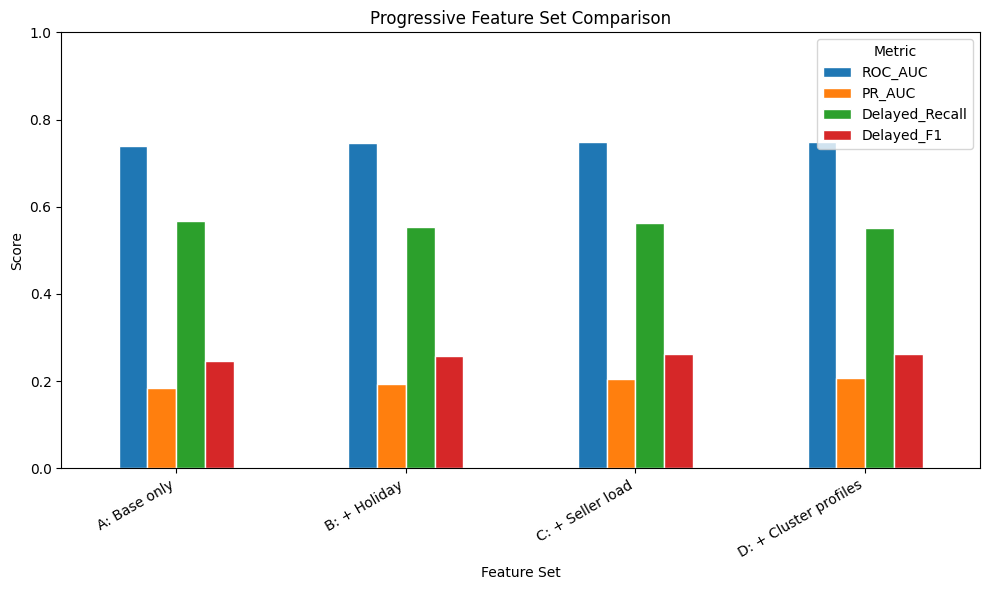

In [73]:
# ============================================================
# Visualise progressive feature set comparison
# ============================================================
# Focus on ranking performance and delayed-class detection.

metrics_to_plot = [
    'ROC_AUC',
    'PR_AUC',
    'Delayed_Recall',
    'Delayed_F1'
]

progressive_plot = progressive_results_df.set_index('Feature_Set')[metrics_to_plot]

ax = progressive_plot.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='white'
)

plt.title('Progressive Feature Set Comparison')
plt.ylabel('Score')
plt.xlabel('Feature Set')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

The progressive comparison shows that adding feature groups leads to modest but consistent improvements in overall model performance. ROC-AUC increases from 0.7395 in Set A to 0.7493 in Set D, while PR-AUC also improves from 0.1850 to 0.2074. This suggests that the additional holiday, seller-load, and cluster-profile features provide useful predictive information beyond the base order-level variables.

Set D achieves the highest accuracy, PR-AUC, precision, and F1-score, indicating the most balanced overall performance. However, delayed-class recall is slightly lower than in Set A, suggesting that richer feature sets improve prediction quality and reduce false alarms, but do not necessarily maximise the number of delayed orders detected.

### 6.10 Feature Importance Analysis

To interpret the final Random Forest model, I examine feature importance scores from the full feature set. These scores indicate which variables contribute most to the model's prediction decisions.

This analysis helps connect model performance back to logistics and business explanations, especially whether engineered features such as seller concurrent load and cluster profiles provide visible predictive signals.

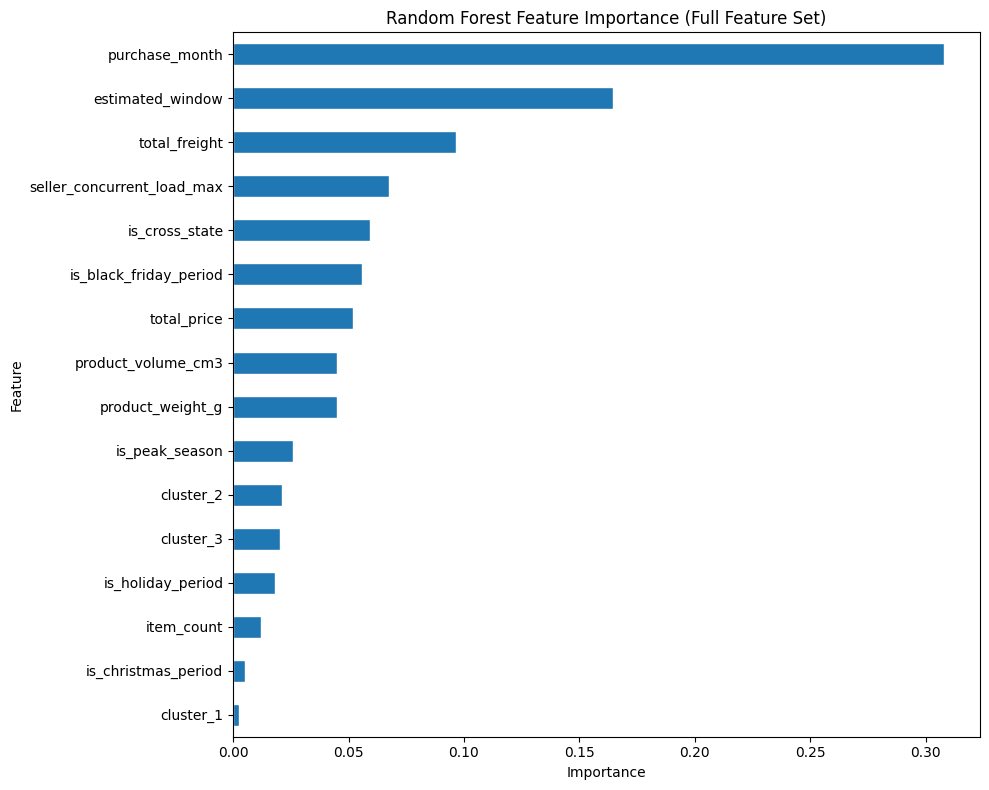

Top 10 features:


,0
purchase_month,0.3082
estimated_window,0.1646
total_freight,0.0967
seller_concurrent_load_max,0.0676
is_cross_state,0.0595
is_black_friday_period,0.0560
total_price,0.0520
product_volume_cm3,0.0449
product_weight_g,0.0448
is_peak_season,0.0261


In [74]:
# ============================================================
# 6.10 Feature importance analysis
# ============================================================
# Use feature importance from the final Random Forest model trained on the full feature set.

importances = pd.Series(
    rf.feature_importances_,
    index=features_set_D
).sort_values(ascending=True)

# Plot feature importance
plt.figure(figsize=(10, 8))
importances.plot(kind='barh', edgecolor='white')

plt.title('Random Forest Feature Importance (Full Feature Set)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Display the top 10 most important features
top_10_importances = importances.sort_values(ascending=False).head(10)

print("Top 10 features:")
display(top_10_importances.round(4))

The feature importance results show that temporal and logistics-related variables are the strongest predictors in the Random Forest model. `purchase_month` and `estimated_window` have the highest importance scores, suggesting that seasonality and the promised delivery window are central to delay prediction.

Several engineered logistics features also appear among the top predictors. `seller_concurrent_load_max` is the fourth most important feature, indicating that seller workload provides useful predictive signal. Holiday-related indicators such as `is_black_friday_period` and `is_peak_season` also contribute to the model, although their importance is lower than the main order-level variables.

Overall, the results suggest that delay risk is shaped by a combination of timing, delivery expectations, freight characteristics, seller workload, and seasonal demand conditions.


### 6.11 Diagnostic Analysis

This section provides a diagnostic analysis of where delivery delays originate in the fulfilment process. I decompose total delivery time into three stages: approval time, seller processing time, and carrier transit time.

These variables are based on timestamps that are only available after delivery is completed. Therefore, they are not included as predictors in the supervised models, because doing so would create data leakage. Instead, they are used diagnostically to understand the operational mechanisms behind delayed deliveries.

In [75]:
# ============================================================
# 6.11 Diagnostic analysis: delivery leg decomposition
# ============================================================
# Decompose delivery time to identify whether delays mainly arise from approval,
# seller processing, or carrier transit.

# Purchase to approval
df['approval_time_days'] = (
    df['order_approved_at'] - df['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

# Approval to carrier handover
df['seller_processing_days'] = (
    df['order_delivered_carrier_date'] - df['order_approved_at']
).dt.total_seconds() / (24 * 3600)

# Carrier handover to customer delivery
df['carrier_delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_delivered_carrier_date']
).dt.total_seconds() / (24 * 3600)

# Treat negative durations as timestamp anomalies
duration_cols = [
    'approval_time_days',
    'seller_processing_days',
    'carrier_delivery_days'
]

for col in duration_cols:
    df.loc[df[col] < 0, col] = np.nan

# Summarise stage durations by delay status
leg_summary = df.groupby('is_delayed').agg(
    order_count=('order_id', 'count'),
    avg_approval_time=('approval_time_days', 'mean'),
    avg_seller_processing=('seller_processing_days', 'mean'),
    avg_carrier_delivery=('carrier_delivery_days', 'mean'),
    avg_total_delivery=('delivery_days', 'mean')
).round(2)

leg_summary.index = leg_summary.index.map({
    0: 'On-time / Early',
    1: 'Delayed'
})

print("Delivery leg decomposition by delay status")
display(leg_summary)

Delivery leg decomposition by delay status


,order_count,avg_approval_time,avg_seller_processing,avg_carrier_delivery,avg_total_delivery
is_delayed,,,,,
On-time / Early,89936,0.42,2.65,7.99,11.00
Delayed,6534,0.51,5.57,27.89,33.95


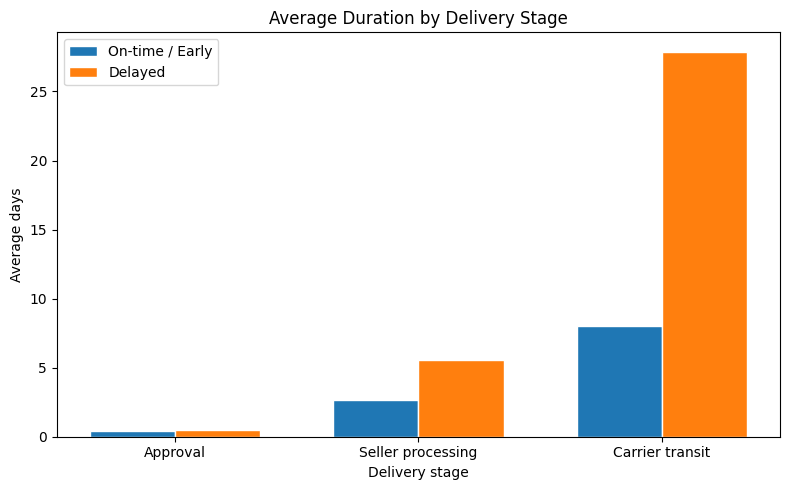

In [76]:
# ============================================================
# Visualise delivery leg decomposition
# ============================================================
# Visualise average stage durations to identify where delayed orders spend additional time.

legs = [
    'avg_approval_time',
    'avg_seller_processing',
    'avg_carrier_delivery'
]

leg_labels = [
    'Approval',
    'Seller processing',
    'Carrier transit'
]

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(leg_labels))
width = 0.35

on_time = leg_summary.loc['On-time / Early', legs].values
delayed = leg_summary.loc['Delayed', legs].values

ax.bar(
    x - width / 2,
    on_time,
    width,
    label='On-time / Early',
    edgecolor='white'
)

ax.bar(
    x + width / 2,
    delayed,
    width,
    label='Delayed',
    edgecolor='white'
)

ax.set_xlabel('Delivery stage')
ax.set_ylabel('Average days')
ax.set_title('Average Duration by Delivery Stage')
ax.set_xticks(x)
ax.set_xticklabels(leg_labels)
ax.legend()
plt.tight_layout()
plt.show()

In [77]:
# ============================================================
# Delivery legs by seller load level
# ============================================================
# Compare delivery stages by seller load level to examine whether high seller load
# is associated with longer processing time and higher delay rate.

leg_by_load = df.groupby('is_high_seller_load').agg(
    order_count=('order_id', 'count'),
    avg_seller_processing=('seller_processing_days', 'mean'),
    avg_carrier_delivery=('carrier_delivery_days', 'mean'),
    delay_rate=('is_delayed', 'mean')
).round(3)

leg_by_load.index = leg_by_load.index.map({
    0: 'Normal load',
    1: 'High load'
})

print("Delivery legs by seller load level")
display(leg_by_load)

Delivery legs by seller load level


,order_count,avg_seller_processing,avg_carrier_delivery,delay_rate
is_high_seller_load,,,,
Normal load,75431,2.759,8.983,0.061
High load,21039,3.189,10.587,0.091


The diagnostic analysis shows that delayed orders mainly spend extra time in the carrier transit stage. Delayed orders take 27.89 days on average from carrier handover to customer delivery, compared with only 7.99 days for on-time or early orders. Seller processing time is also longer for delayed orders, but the difference is smaller.

Seller workload still provides useful explanatory signal. High-load sellers have longer seller processing time, longer carrier delivery time, and a higher delay rate than normal-load sellers. This suggests that seller load contributes to delay risk, while the largest operational bottleneck appears to occur during carrier transit.

## 7. Results & Business Recommendations

### 7.1 Key Results Summary

This project analysed Olist logistics delivery performance by combining order-level data with external Brazilian public holiday and peak-season indicators. The final cleaned dataset contains 96,470 delivered orders. The target variable is highly imbalanced: only 6.77% of orders are delayed, while 93.23% are delivered on time or earlier than the estimated date.

The exploratory analysis shows that delayed orders are strongly associated with poorer customer experience. Delayed orders have an average review score of 2.27, compared with 4.29 for on-time or early orders. This means that delivery delay is a minority event, but it is still business-critical.

Several logistics and contextual factors are associated with delivery risk. Cross-state orders have a higher delay rate than same-state orders, suggesting that route complexity matters. Black Friday-period orders also show a much higher delay rate than general public holiday or Christmas-period orders, indicating that demand-surge periods create stronger delivery pressure than public holidays in general.

The K-Means clustering analysis identifies four logistics order profiles: local low-risk orders, heavy bulky high-freight orders, peak-season high-delay orders, and standard cross-state orders. The highest delay rate appears in the peak-season cluster, showing that delay risk is concentrated in specific operational contexts rather than evenly distributed across all orders.

In supervised learning, Logistic Regression, a tuned Decision Tree, Random Forest, and XGBoost are compared using the expanded feature set. XGBoost achieves the highest ROC-AUC, PR-AUC, and delayed-class recall, making it the strongest early-warning model for identifying potentially delayed orders. Random Forest achieves the highest accuracy and delayed-class F1-score, suggesting a more balanced but more conservative prediction pattern.

The progressive feature comparison shows that adding holiday indicators, seller concurrent load, and cluster profiles improves model performance beyond baseline order-level features. Feature importance analysis further shows that `seller_concurrent_load_max`, `is_black_friday_period`, and `is_peak_season` provide useful predictive signals. Finally, the diagnostic delivery-leg analysis shows that the largest bottleneck occurs during carrier transit, while high seller load is also associated with longer processing time and higher delay rates.


In [78]:
# ============================================================
# 7.1 Model results summary table
# ============================================================
# Build a concise final model comparison table using the main evaluation metrics.

results_summary = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Tuned Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logit),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_prob_logit),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    'PR_AUC': [
        average_precision_score(y_test, y_prob_logit),
        average_precision_score(y_test, y_prob_tree),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ],
    'Delayed_Recall': [
        recall_score(y_test, y_pred_logit, zero_division=0),
        recall_score(y_test, y_pred_tree, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0)
    ],
    'Delayed_F1': [
        f1_score(y_test, y_pred_logit, zero_division=0),
        f1_score(y_test, y_pred_tree, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0)
    ]
}).round(4)

results_summary = results_summary.sort_values(
    by='ROC_AUC',
    ascending=False
).reset_index(drop=True)

display(results_summary)

,Model,Accuracy,ROC_AUC,PR_AUC,Delayed_Recall,Delayed_F1
0,XGBoost,0.7276,0.7643,0.2179,0.6656,0.2487
1,Random Forest,0.7902,0.7493,0.2074,0.5516,0.2627
2,Tuned Decision Tree,0.7160,0.7307,0.1816,0.6320,0.2317
3,Logistic Regression,0.6337,0.6858,0.1488,0.6236,0.1874


The final model comparison shows that XGBoost achieved the strongest overall ranking performance, with the highest ROC-AUC, PR-AUC, and delayed-class recall. This makes XGBoost the most suitable model if the main objective is to identify as many potentially delayed orders as possible.

Random Forest achieved the highest accuracy and delayed-class F1-score, suggesting a more balanced prediction pattern with fewer false alarms. Therefore, XGBoost is better for an early-warning use case, while Random Forest may be preferable if the business wants a more conservative model.

### 7.2 Business Recommendations

**1. Use XGBoost as an early-warning tool for high-risk orders.**
The final model comparison shows that XGBoost achieved the highest ROC-AUC, PR-AUC, and delayed-class recall. This makes it suitable for identifying potentially delayed orders before they become customer-facing problems. However, because delayed orders are highly imbalanced and precision remains limited, the model should not be used as a definitive decision system. Instead, it should be used to prioritise monitoring, proactive tracking, and customer communication.

**2. Use Random Forest when the business needs a more conservative risk filter.**
Random Forest achieved the highest accuracy and delayed-class F1-score. Compared with XGBoost, it is less aggressive in flagging delayed orders and produces fewer false alarms. Therefore, Olist could use XGBoost when the priority is to detect as many risky orders as possible, and Random Forest when the priority is to balance risk detection with operational efficiency.

**3. Strengthen planning for Black Friday and peak-season periods.**
The analysis shows that demand-surge periods, especially the Black Friday period, are associated with higher delay risk. `is_black_friday_period` and `is_peak_season` also appear among the important predictive features. Olist should therefore prepare additional seller support, carrier capacity, and customer-service resources before peak-demand periods, rather than treating all public holidays as equally risky.

**4. Monitor seller workload as an operational risk signal.**
The seller concurrent load feature appears among the top predictors in the Random Forest model. The diagnostic analysis also shows that high-load sellers have longer seller processing time, longer carrier delivery time, and a higher delay rate than normal-load sellers. Olist could build a seller workload dashboard to flag sellers with unusually high active order volumes and provide earlier support during demand surges.

**5. Use cluster profiles to identify high-risk logistics contexts.**
The K-Means clustering analysis shows that delay risk is concentrated in specific order profiles, especially peak-season high-delay orders and more complex logistics cases. Since adding cluster profiles improves the Random Forest model’s PR-AUC and delayed-class F1-score, these cluster labels can help Olist segment orders into operational risk groups. This could support differentiated monitoring strategies rather than applying the same logistics rules to all orders.

**6. Focus on carrier transit as the main delivery bottleneck.**
The delivery-leg decomposition shows that the largest difference between delayed and on-time orders occurs during carrier transit. Delayed orders spend 27.89 days on average in carrier delivery, compared with 7.99 days for on-time or early orders. This suggests that improving seller processing alone is not enough. Olist should work with carrier partners to identify risky routes, cross-state delivery bottlenecks, and regions with consistently long transit times.

**7. Improve delivery promise management.**
Olist should make estimated delivery dates more dynamic by accounting for order timing, route complexity, seller workload, cluster profile, and peak-season pressure. For high-risk orders, more conservative delivery estimates and proactive updates may reduce customer dissatisfaction even when delays cannot be fully avoided.


### 7.3 Limitations and Future Improvements

This project has several limitations. First, the target variable is highly imbalanced, which makes delayed-order prediction difficult and limits precision and F1-score. Second, some important operational information is missing, such as actual seller-customer distance, carrier provider, route capacity, weather, and regional disruption data. Third, diagnostic variables such as seller processing time and carrier transit time are only available after delivery is completed, so they cannot be used as predictors without causing data leakage. Future work could improve the model by adding richer seller-level, carrier-level, geographic, and external disruption data, and by building separate prediction models for different stages of the fulfilment process.

### 7.4 Final Conclusion

Overall, this project shows that Olist delivery delay is a rare but business-critical outcome. Delayed orders are associated with much lower customer review scores, and delay risk is concentrated in specific contexts such as cross-state delivery, Black Friday and peak-season periods, high seller workload, and certain logistics clusters. XGBoost is the strongest early-warning model, while Random Forest provides a more conservative alternative. The main business value of the analysis is to help Olist identify high-risk orders earlier, prioritise monitoring, improve delivery promise management, and guide future data collection around seller capacity, carrier performance, and route complexity.